# DEEP LEARNING PR 3
## Classical Image Processing + YuNet Face Detection + YOLOv8 Object Detection

This notebook follows the project tasks in order:
1. Morphological operations
2. Bitwise operations and image histograms
3. Face detection with YuNet
4. Object detection with YOLOv8
5. Integrated pipeline and final comparison

# Import All Libraries

In [ ]:
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Import os for folder and file handling
import os

# Import time for FPS calculation
import time

# Display OpenCV version
print("OpenCV Version:", cv2.__version__)

OpenCV Version: 5.0.0


## Create Project Folders

In [2]:
# Create images folder
os.makedirs("data/images", exist_ok=True)

# Create models folder
os.makedirs("data/models", exist_ok=True)

# # Create output folder
# os.makedirs("outputs", exist_ok=True)

print("Folders created successfully.")

Folders created successfully.


## Load Original image

Image loaded successfully.


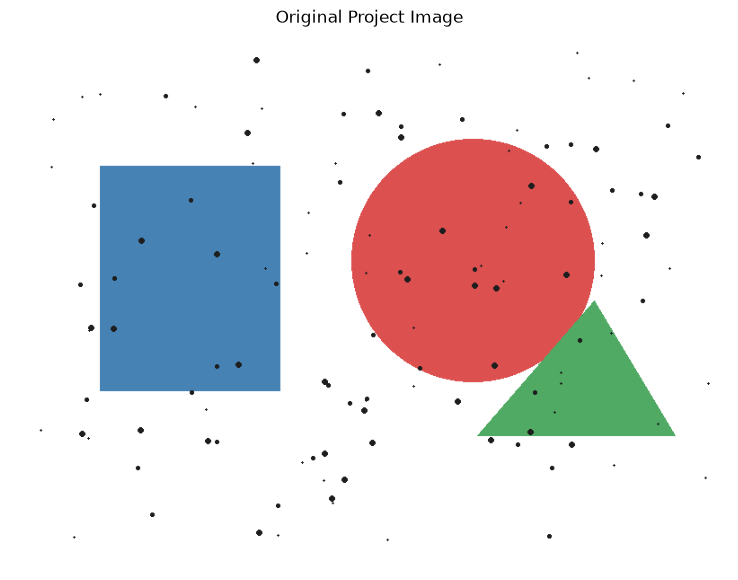

In [ ]:
# Path of our downloaded original image
image_path = "data/images/project_original.png"

# Read the image
img = cv2.imread(image_path)

# Check if image loaded
if img is None:
    print("Image not found.")
    print("Please put project_original.png inside data/images/")
else:
    print("Image loaded successfully.")

# Display image
plt.figure(figsize=(10, 7))

# OpenCV reads BGR, so convert BGR to RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Show image
plt.imshow(img_rgb)

# Add title
plt.title("Original Project Image")

# Hide axes
plt.axis("off")

# Show image
plt.show()

## Image Information

In [ ]:
# Get image height
height = img.shape[0]

# Get image width
width = img.shape[1]

# Get number of channels
channels = img.shape[2]

# Print image information
print("Image Height:", height)
print("Image Width:", width)
print("Number of Channels:", channels)

Image Height: 600
Image Width: 800
Number of Channels: 3


# Morphological Operations
## Convert Original image to grayscale

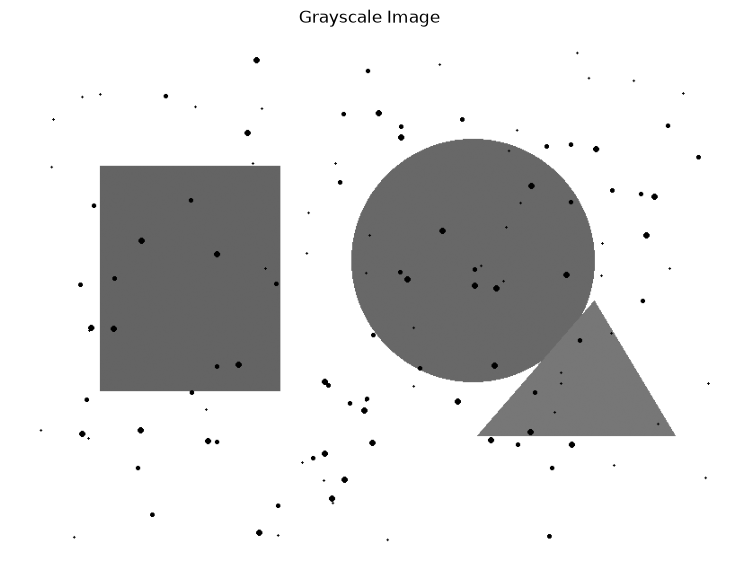

In [ ]:
# Convert original BGR image to grayscale
gray = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2GRAY
)

# Display grayscale image
plt.figure(figsize=(10, 7))

plt.imshow(
    gray,
    cmap="gray"
)

plt.title("Grayscale Image")

plt.axis("off")

plt.show()

## Use Grayscale Image

Downloaded grayscale image loaded successfully.


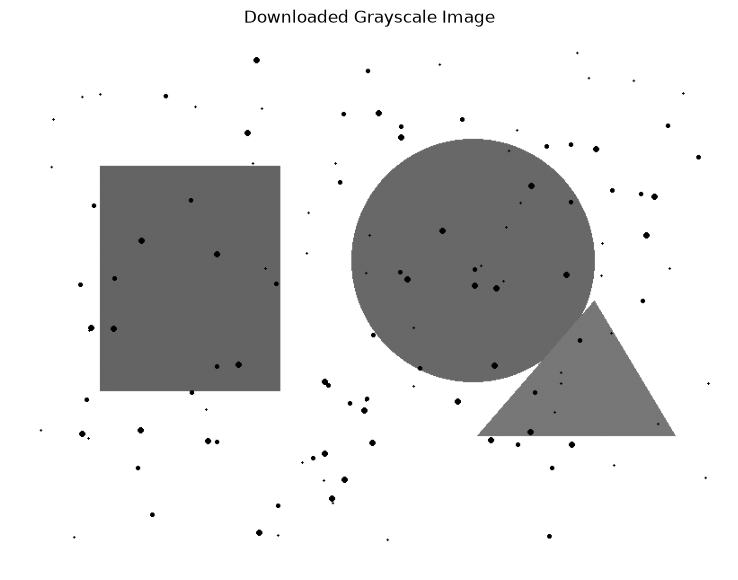

In [ ]:
# Path of downloaded grayscale image
gray_path = "data/images/project_grayscale.png"

# Read grayscale image
gray_downloaded = cv2.imread(
    gray_path,
    cv2.IMREAD_GRAYSCALE
)

# Check image
if gray_downloaded is None:
    print("Grayscale image not found.")
else:
    print("Downloaded grayscale image loaded successfully.")

# Display
plt.figure(figsize=(10, 7))

plt.imshow(
    gray_downloaded,
    cmap="gray"
)

plt.title("Downloaded Grayscale Image")

plt.axis("off")

plt.show()

## Convert Grayscale to Binary

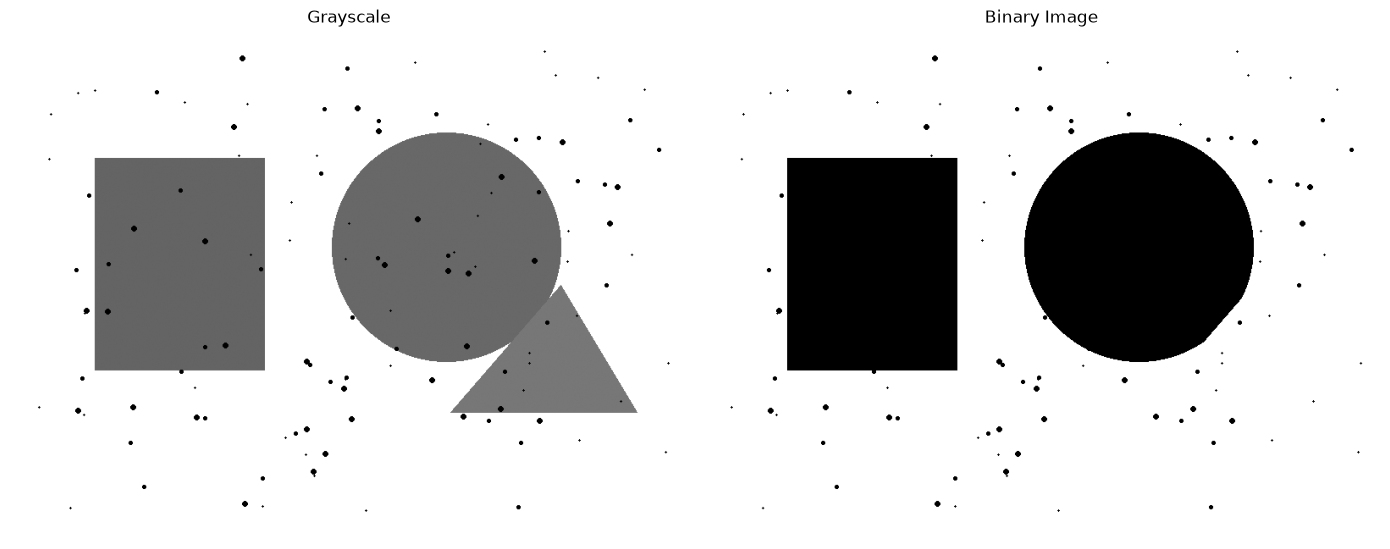

In [ ]:
# Apply binary threshold
threshold_value = 127

# Create binary image
_, binary = cv2.threshold(
    gray,
    threshold_value,
    255,
    cv2.THRESH_BINARY
)

# Display grayscale and binary
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)

plt.imshow(
    gray,
    cmap="gray"
)

plt.title("Grayscale")

plt.axis("off")


plt.subplot(1, 2, 2)

plt.imshow(
    binary,
    cmap="gray"
)

plt.title("Binary Image")

plt.axis("off")

plt.tight_layout()

plt.show()

## Create 5×5 Rectangular Kernel

In [ ]:
# Create a 5x5 rectangular kernel
kernel = np.ones(
    (5, 5),
    np.uint8
)

# Display kernel
print(kernel)

[[1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]]


## Erosion
Erosion removes small white regions
and makes foreground objects smaller.

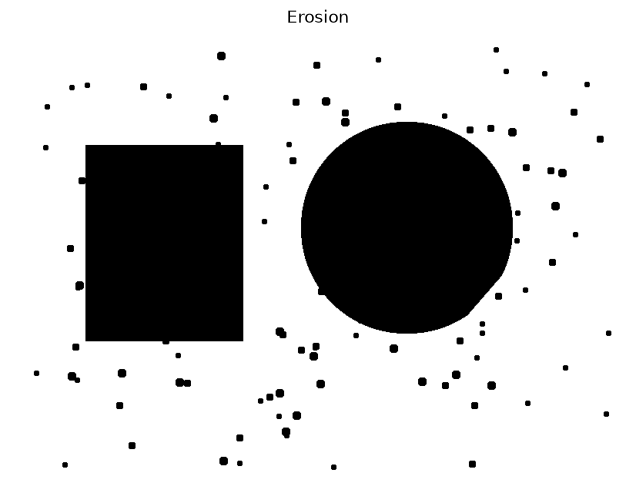

In [ ]:
# Apply erosion
erosion = cv2.erode(
    binary,
    kernel,
    iterations=1
)

plt.figure(figsize=(8, 6))
plt.imshow(
    erosion,
    cmap="gray"
)

plt.title("Erosion")
plt.axis("off")
plt.show()

## Dilation
Dilation expands white foreground regions
and can fill small gaps.

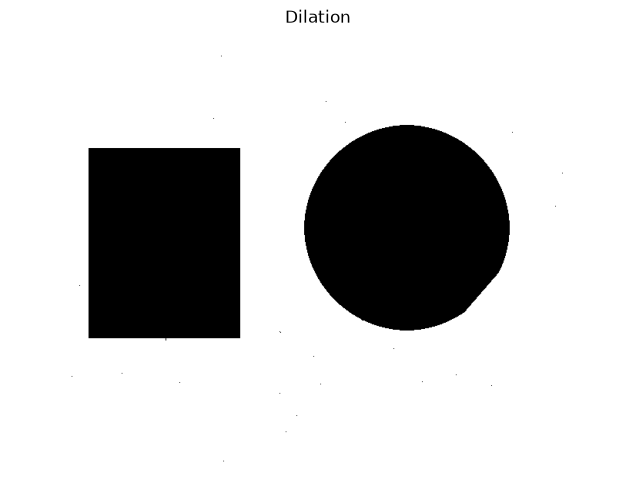

In [ ]:
# Apply dilation
dilation = cv2.dilate(
    binary,
    kernel,
    iterations=1
)

plt.figure(figsize=(8, 6))
plt.imshow(
    dilation,
    cmap="gray"
)

plt.title("Dilation")
plt.axis("off")
plt.show()

## Opening
Opening = Erosion + Dilation

It is useful for removing small noise.

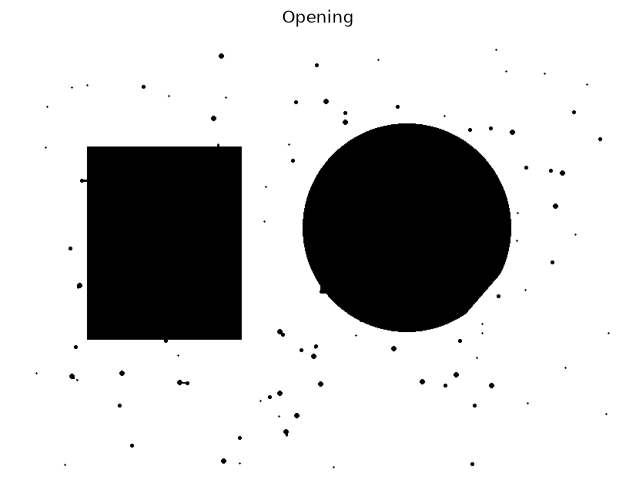

In [ ]:
    # Apply opening
opening = cv2.morphologyEx(
    binary,
    cv2.MORPH_OPEN,
    kernel
)

plt.figure(figsize=(8, 6))
plt.imshow(
    opening,
    cmap="gray"
)

plt.title("Opening")
plt.axis("off")
plt.show()

## Closing
Closing = Dilation + Erosion

It is useful for filling small holes and gaps.

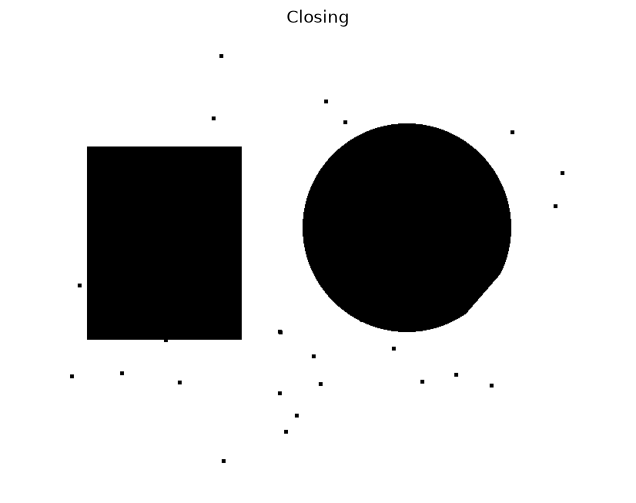

In [ ]:
# Apply closing
closing = cv2.morphologyEx(
    binary,
    cv2.MORPH_CLOSE,
    kernel
)

plt.figure(figsize=(8, 6))
plt.imshow(
    closing,
    cmap="gray"
)

plt.title("Closing")
plt.axis("off")
plt.show()

## Display All Morphological Operations

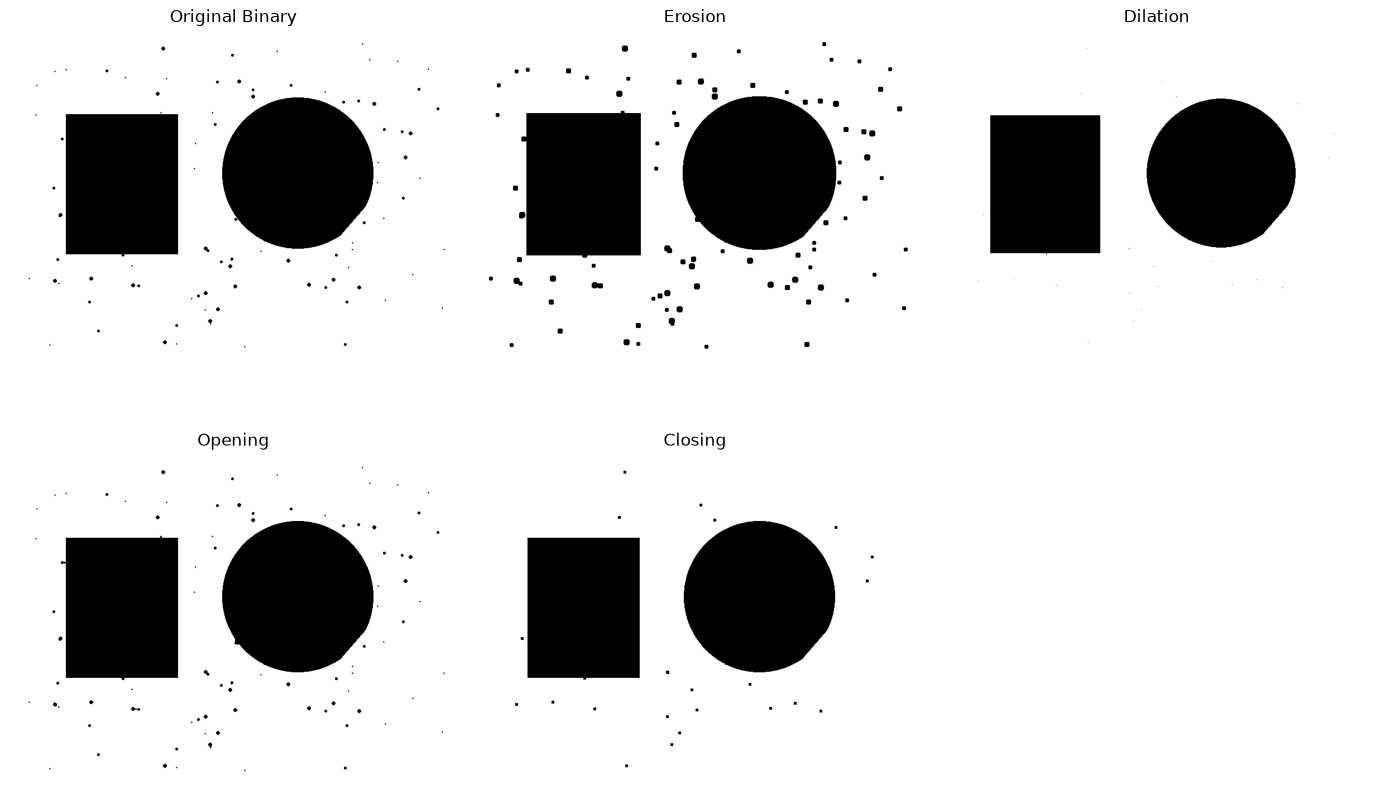

In [ ]:
# Create large figure
plt.figure(figsize=(14, 9))

# Original binary
plt.subplot(2, 3, 1)
plt.imshow(binary, cmap="gray")
plt.title("Original Binary")
plt.axis("off")

# Erosion
plt.subplot(2, 3, 2)
plt.imshow(erosion, cmap="gray")
plt.title("Erosion")
plt.axis("off")

# Dilation
plt.subplot(2, 3, 3)
plt.imshow(dilation, cmap="gray")
plt.title("Dilation")
plt.axis("off")

# Opening
plt.subplot(2, 3, 4)
plt.imshow(opening, cmap="gray")
plt.title("Opening")
plt.axis("off")

# Closing
plt.subplot(2, 3, 5)
plt.imshow(closing, cmap="gray")
plt.title("Closing")
plt.axis("off")

plt.tight_layout()

plt.show()

#  Kernel Shape and Size Comparison

The assignment requires:

*  RECT
*  ELLIPSE
*  CROSS

with:

*  3×3
*  5×5
*  9×9

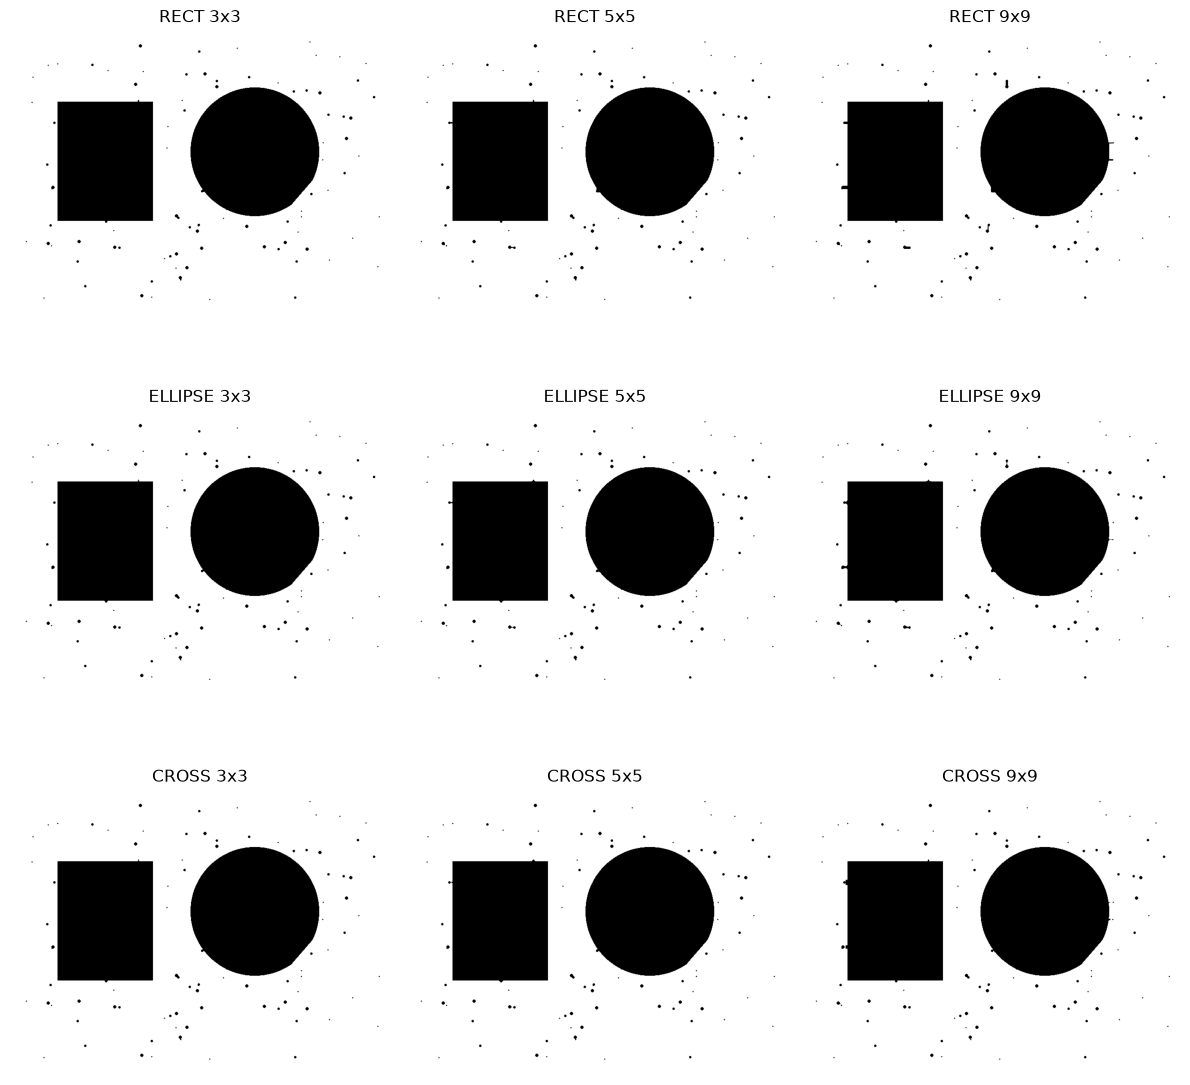

In [ ]:
# Define kernel shapes
kernel_shapes = {
    "RECT": cv2.MORPH_RECT,
    "ELLIPSE": cv2.MORPH_ELLIPSE,
    "CROSS": cv2.MORPH_CROSS
}

# Define kernel sizes
kernel_sizes = [3, 5, 9]

plt.figure(figsize=(12, 12))

# Start subplot number
plot_number = 1

# Loop through shapes
for shape_name, shape_type in kernel_shapes.items():

    # Loop through sizes
    for size in kernel_sizes:

        # Create kernel
        current_kernel = cv2.getStructuringElement(
            shape_type,
            (size, size)
        )

        # Apply opening
        result = cv2.morphologyEx(
            binary,
            cv2.MORPH_OPEN,
            current_kernel
        )

        plt.subplot(3, 3, plot_number)
        plt.imshow(result,cmap="gray")

        plt.title(shape_name + " " + str(size) + "x" + str(size))

        plt.axis("off")
        plot_number += 1

plt.tight_layout()
plt.show()

# WHY morphology works

Erosion removes small white regions and shrinks foreground objects.

Dilation expands foreground regions and can fill small gaps.

Opening is useful for removing small salt-and-pepper noise while
preserving the general shape of an object.

Closing is useful for filling small holes and connecting small gaps.

A small kernel such as 3x3 or 5x5 is usually safer because a very
large kernel such as 9x9 can remove important object details.

# TASK 2: Bitwise Operations and Histograms
## Create Two Masks

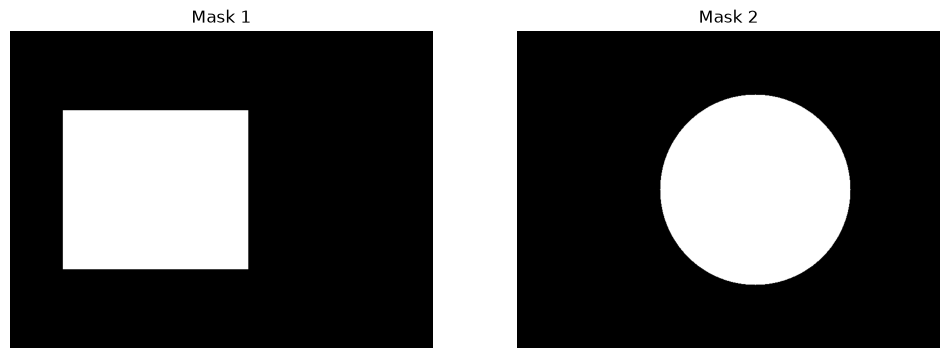

In [ ]:
# Create black mask
mask1 = np.zeros((600, 800),dtype=np.uint8)

# Create second black mask
mask2 = np.zeros(
    (600, 800),
    dtype=np.uint8
)

# Draw rectangle on mask 1
cv2.rectangle(
    mask1,
    (100, 150),
    (450, 450),
    255,
    -1
)

# Draw circle on mask 2
cv2.circle(
    mask2,
    (450, 300),
    180,
    255,
    -1
)

# Display masks
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(mask1,cmap="gray")
plt.title("Mask 1")
plt.axis("off")


plt.subplot(1, 2, 2)
plt.imshow(mask2,cmap="gray")
plt.title("Mask 2")
plt.axis("off")
plt.show()

## AND

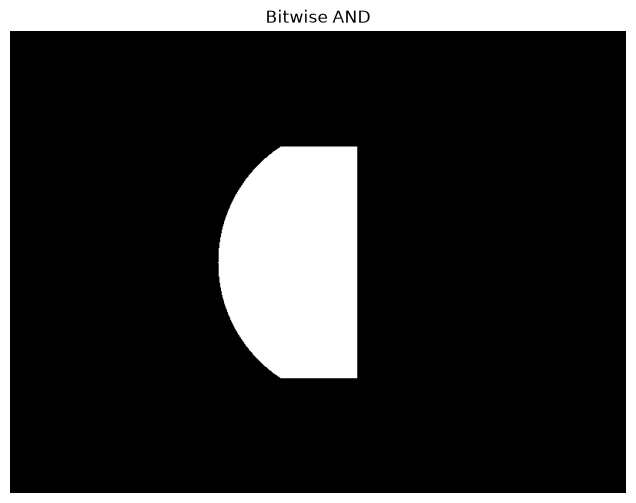

In [ ]:
# Bitwise AND
bitwise_and = cv2.bitwise_and(
    mask1,
    mask2
)

plt.figure(figsize=(8, 6))
plt.imshow(
    bitwise_and,
    cmap="gray"
)
plt.title("Bitwise AND")
plt.axis("off")
plt.show()

## OR

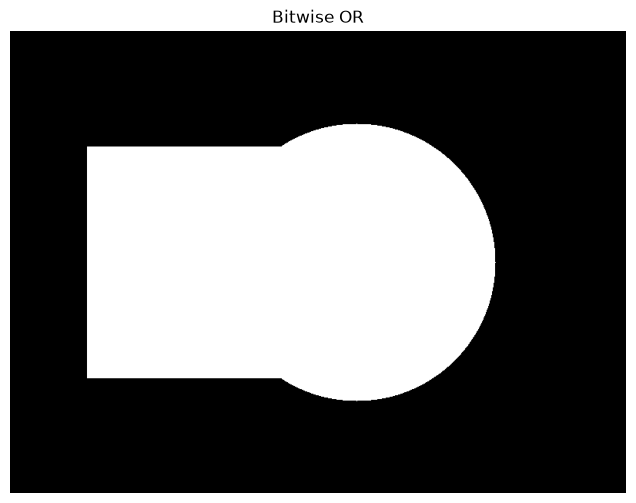

In [ ]:
bitwise_or = cv2.bitwise_or(
    mask1,
    mask2
)

plt.figure(figsize=(8, 6))
plt.imshow(
    bitwise_or,
    cmap="gray"
)
plt.title("Bitwise OR")
plt.axis("off")
plt.show()

## XOR

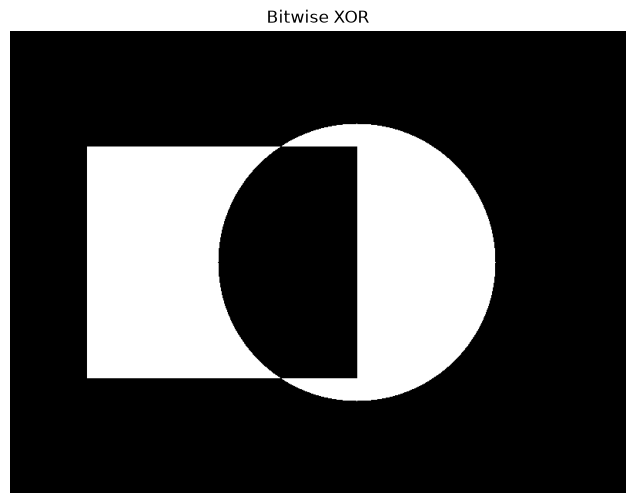

In [ ]:
bitwise_xor = cv2.bitwise_xor(
    mask1,
    mask2
)

plt.figure(figsize=(8, 6))
plt.imshow(
    bitwise_xor,
    cmap="gray"
)
plt.title("Bitwise XOR")
plt.axis("off")
plt.show()

## Not

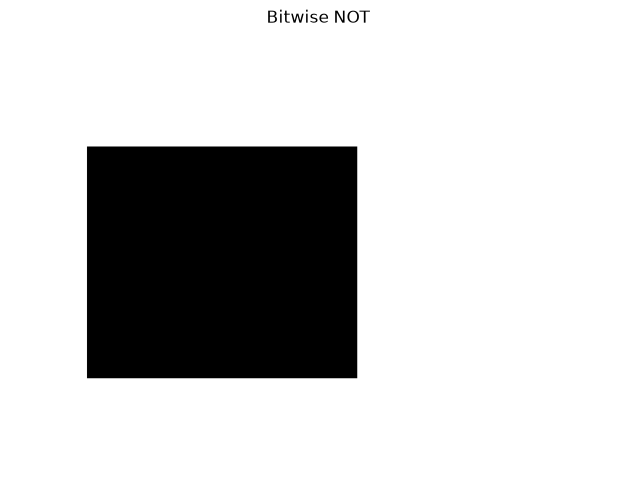

In [ ]:
bitwise_not = cv2.bitwise_not(
    mask1
)

plt.figure(figsize=(8, 6))
plt.imshow(
    bitwise_not,
    cmap="gray"
)
plt.title("Bitwise NOT")
plt.axis("off")
plt.show()

## All Bitwise Operations

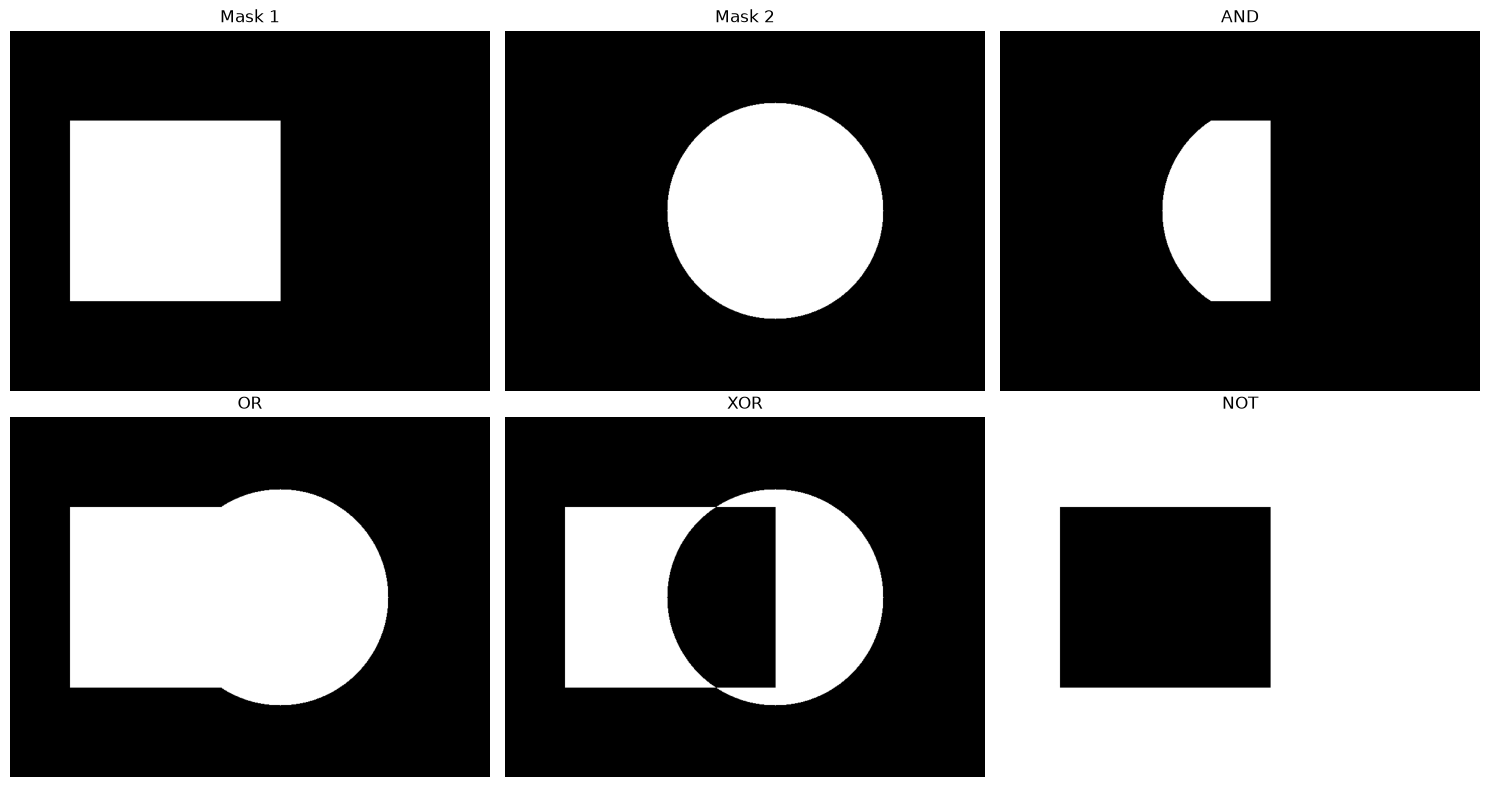

In [ ]:
# Display all bitwise results
plt.figure(figsize=(15, 8))

plt.subplot(2, 3, 1)
plt.imshow(mask1, cmap="gray")
plt.title("Mask 1")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(mask2, cmap="gray")
plt.title("Mask 2")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(bitwise_and, cmap="gray")
plt.title("AND")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(bitwise_or, cmap="gray")
plt.title("OR")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(bitwise_xor, cmap="gray")
plt.title("XOR")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(bitwise_not, cmap="gray")
plt.title("NOT")
plt.axis("off")

plt.tight_layout()

plt.show()

## Apply Mask

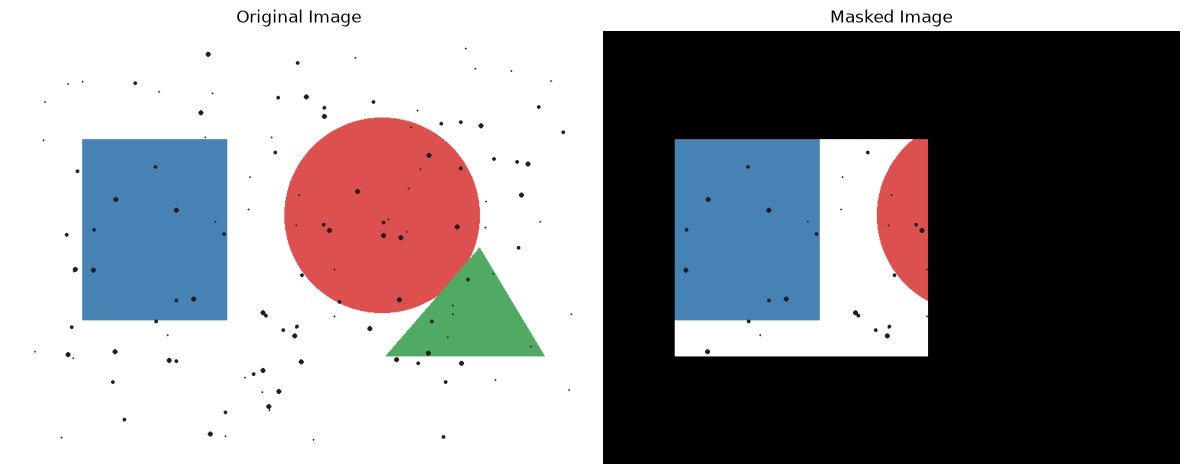

In [ ]:
# Resize mask to match image
mask_for_image = cv2.resize(
    mask1,
    (img.shape[1], img.shape[0])
)

# Apply mask
masked_image = cv2.bitwise_and(
    img,
    img,
    mask=mask_for_image
)

# Display result
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(
    cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )
)
plt.title("Original Image")
plt.axis("off")


plt.subplot(1, 2, 2)
plt.imshow(
    cv2.cvtColor(
        masked_image,
        cv2.COLOR_BGR2RGB
    )
)

plt.title("Masked Image")
plt.axis("off")
plt.tight_layout()
plt.show()

## Grayscale Histogram

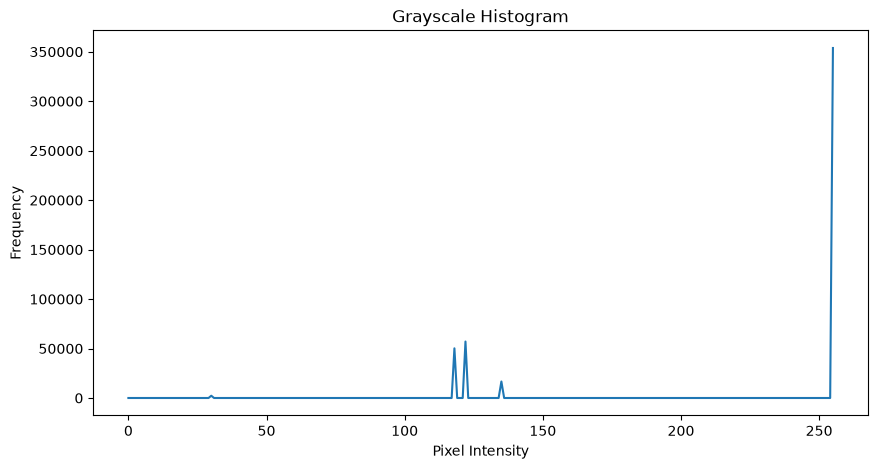

In [ ]:
# Calculate grayscale histogram
gray_histogram = cv2.calcHist(
    [gray],
    [0],
    None,
    [256],
    [0, 256]
)

# Plot histogram
plt.figure(figsize=(10, 5))
plt.plot(gray_histogram)
plt.title("Grayscale Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.show()

## Colour Histogram

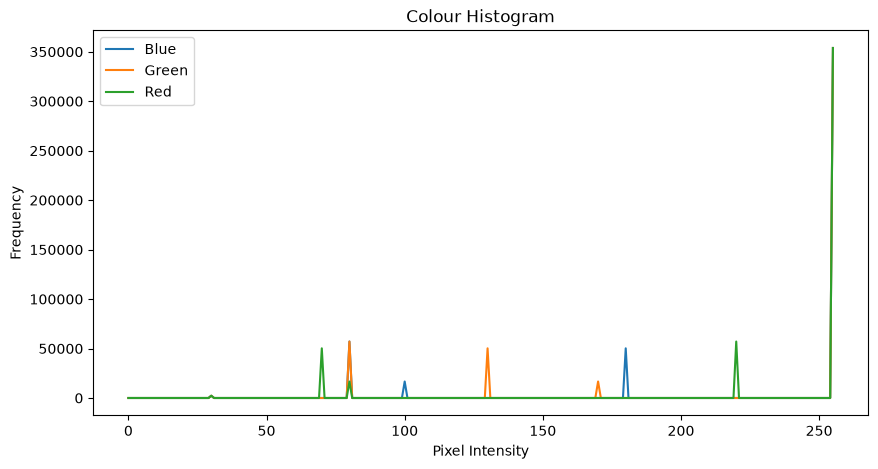

In [ ]:
# Calculate blue histogram
blue_hist = cv2.calcHist(
    [img],
    [0],
    None,
    [256],
    [0, 256]
)

# Calculate green histogram
green_hist = cv2.calcHist(
    [img],
    [1],
    None,
    [256],
    [0, 256]
)

# Calculate red histogram
red_hist = cv2.calcHist(
    [img],
    [2],
    None,
    [256],
    [0, 256]
)

# Plot colour histograms
plt.figure(figsize=(10, 5))
plt.plot(
    blue_hist,
    label="Blue"
)

plt.plot(
    green_hist,
    label="Green"
)

plt.plot(red_hist,label="Red")
plt.title("Colour Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.legend()
plt.show()

## Brightness and Contrast

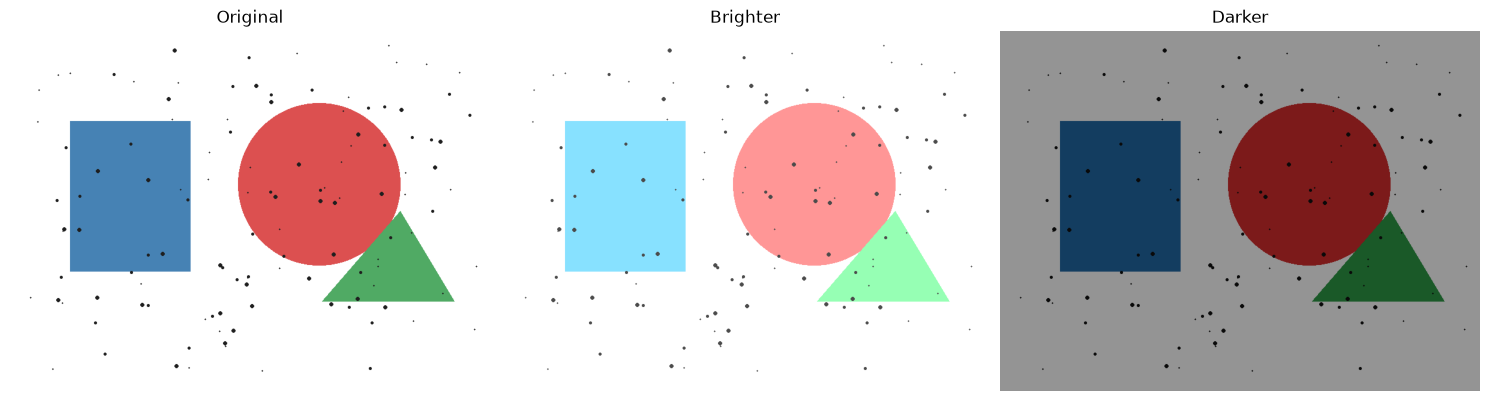

In [ ]:
# Increase brightness and contrast
bright_image = cv2.convertScaleAbs(
    img,
    alpha=1.5,
    beta=30
)

# Decrease brightness and contrast
dark_image = cv2.convertScaleAbs(
    img,
    alpha=0.7,
    beta=-30
)

# Display images
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(
    cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )
)
plt.title("Original")
plt.axis("off")


plt.subplot(1, 3, 2)
plt.imshow(
    cv2.cvtColor(
        bright_image,
        cv2.COLOR_BGR2RGB
    )
)
plt.title("Brighter")
plt.axis("off")


plt.subplot(1, 3, 3)
plt.imshow(
    cv2.cvtColor(
        dark_image,
        cv2.COLOR_BGR2RGB
    )
)

plt.title("Darker")
plt.axis("off")
plt.tight_layout()
plt.show()

## Brightness Histograms

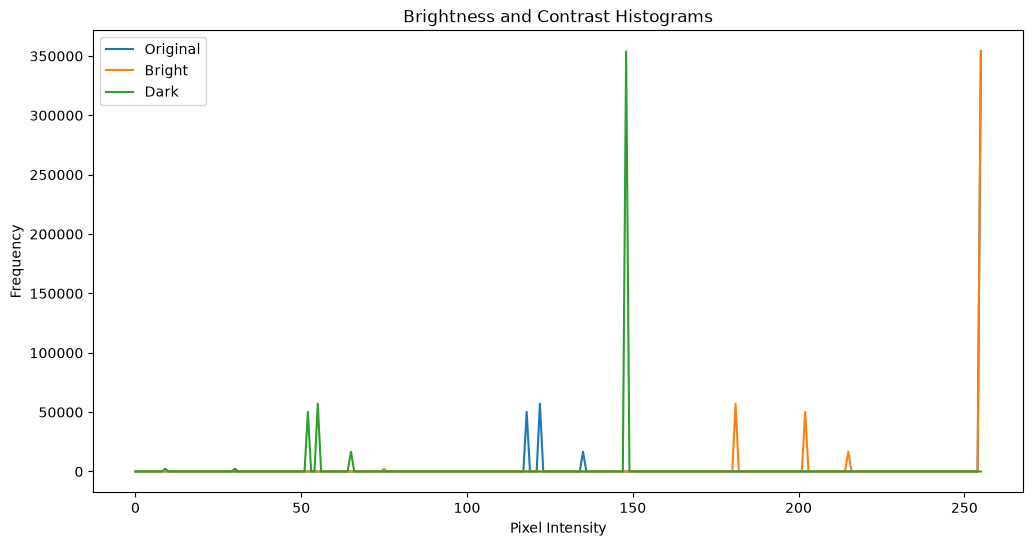

In [ ]:
# Convert bright image to grayscale
bright_gray = cv2.cvtColor(
    bright_image,
    cv2.COLOR_BGR2GRAY
)

# Convert dark image to grayscale
dark_gray = cv2.cvtColor(
    dark_image,
    cv2.COLOR_BGR2GRAY
)

# Calculate original histogram
hist_original = cv2.calcHist(
    [gray],
    [0],
    None,
    [256],
    [0, 256]
)

# Calculate bright histogram
hist_bright = cv2.calcHist(
    [bright_gray],
    [0],
    None,
    [256],
    [0, 256]
)

# Calculate dark histogram
hist_dark = cv2.calcHist(
    [dark_gray],
    [0],
    None,
    [256],
    [0, 256]
)

# Plot
plt.figure(figsize=(12, 6))
plt.plot(
    hist_original,
    label="Original"
)
plt.plot(
    hist_bright,
    label="Bright"
)
plt.plot(
    hist_dark,
    label="Dark"
)
plt.title("Brightness and Contrast Histograms")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.legend()
plt.show()

# 2.5 WHY alpha/beta and histograms matter

The formula used by `convertScaleAbs` is approximately:

**new_pixel = alpha × old_pixel + beta**

`alpha` controls contrast. Increasing `alpha` increases contrast, while decreasing it reduces contrast.  
`beta` controls brightness. Positive `beta` makes the image brighter and negative `beta` makes it darker.

Histograms show the distribution of pixel intensities. A histogram concentrated at low values usually indicates a dark image. A histogram concentrated at high values usually indicates a bright image. A narrow histogram can indicate low contrast.

These checks are useful before face or object detection because poor lighting and low contrast can reduce detection quality.

# TASK 3 : YuNet Face Detection

# Download YuNet Model

In [3]:
# Import urllib
import urllib.request

# YuNet model URL
yunet_url = (
    "https://github.com/opencv/opencv_zoo/raw/main/"
    "models/face_detection_yunet/"
    "face_detection_yunet_2023mar.onnx"
)

# Model path
yunet_model_path = (
    "data/models/face_detection_yunet_2023mar.onnx"
)

# Download if model doesn't exist
if not os.path.exists(yunet_model_path):

    urllib.request.urlretrieve(
        yunet_url,
        yunet_model_path
    )

    print("YuNet model downloaded.")

else:

    print("YuNet model already exists.")

YuNet model already exists.


In [4]:
print("Model exists:",os.path.exists(yunet_model_path))

print("Model path:",yunet_model_path)

Model exists: True
Model path: data/models/face_detection_yunet_2023mar.onnx


In [5]:
# Folder containing the captured static images
input_folder = "data/images"

# Folder where detected results will be saved
output_folder = "outputs"

# Create output folder if it does not exist
os.makedirs(output_folder, exist_ok=True)

## Capture and Save 4 Images

In [28]:
# Import OpenCV
import cv2

# Import os
import os

# Create folder for captured images
save_folder = "data/images"

# Create folder if it does not exist
os.makedirs(save_folder, exist_ok=True)

# Open webcam
cap = cv2.VideoCapture(0)

# Check whether webcam opened
if not cap.isOpened():
    print("Could not open webcam.")
else:
    print("Webcam opened successfully.")

# Image number
image_number = 1

# Maximum number of images
max_images = 4

# Start webcam loop
while image_number <= max_images:

    # Read frame from webcam
    ret, frame = cap.read()

    # Check frame
    if not ret:
        print("Could not read frame.")
        break

    # Display instructions
    cv2.putText(
        frame,
        "Press S = Save | Q = Quit",
        (20, 40),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (0, 255, 0),
        2
    )

    # Display image number
    cv2.putText(
        frame,
        "Image " + str(image_number) + " of 4",
        (20, 75),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (0, 255, 255),
        2
    )

    # Show webcam
    cv2.imshow(
        "Capture Static Images",
        frame
    )

    # Wait for keyboard input
    key = cv2.waitKey(1) & 0xFF

    # Press S to save
    if key == ord("s") or key == ord("S"):

        # Create image filename
        filename = (
            save_folder
            + "/person"
            + str(image_number)
            + ".jpg"
        )

        # Save image
        cv2.imwrite(
            filename,
            frame
        )

        # Print saved location
        print(
            "Image saved:",
            filename
        )

        # Move to next image
        image_number += 1

    # Press Q to quit
    elif key == ord("q") or key == ord("Q"):

        print("Camera stopped by user.")
        break

# Release webcam
cap.release()

# Close OpenCV windows
cv2.destroyAllWindows()

# Final message
print("Image capturing completed.")

Webcam opened successfully.
Image saved: data/images/person1.jpg
Image saved: data/images/person2.jpg
Image saved: data/images/person3.jpg
Image saved: data/images/person4.jpg
Image capturing completed.


## Define image path

In [6]:
image_paths = [
    "data/images/person1.jpg",
    "data/images/person2.jpg",
    "data/images/person3.jpg",
    "data/images/person4.jpg"
]

# Display the image paths
print("Images used for YuNet detection:")

for path in image_paths:
    print(path)

Images used for YuNet detection:
data/images/person1.jpg
data/images/person2.jpg
data/images/person3.jpg
data/images/person4.jpg


## Detect faces in all 4 images

In [7]:
# Create an empty list to store output images
result_images = []

# Create an empty list to store detection information
detection_results = []

# Process every image one by one
for image_path in image_paths:

    img = cv2.imread(image_path)

    if img is None:
        print("Could not read:", image_path)
        continue

    # Get image height
    img_h = img.shape[0]

    # Get image width
    img_w = img.shape[1]

    # Create YuNet face detector
    detector = cv2.FaceDetectorYN_create(
        yunet_model_path,
        "",
        (img_w, img_h),
        0.9
    )

    # Set input image size
    detector.setInputSize((img_w, img_h))

    # Detect faces
    _, faces = detector.detect(img)

    # Make a copy of the original image
    output = img.copy()

    # Count detected faces
    face_count = 0

    # Check if faces were detected
    if faces is not None:

        for face in faces:
            face_count += 1

            # Get bounding box coordinates
            x = int(face[0])
            y = int(face[1])
            w = int(face[2])
            h = int(face[3])

            # Draw bounding box
            cv2.rectangle(
                output,
                (x, y),
                (x + w, y + h),
                (0, 255, 0),
                2
            )

            # Get confidence score
            confidence = float(face[14])

            # Get the five facial landmarks
            landmarks = [
                (int(face[4]), int(face[5])),
                (int(face[6]), int(face[7])),
                (int(face[8]), int(face[9])),
                (int(face[10]), int(face[11])),
                (int(face[12]), int(face[13]))
            ]

            # Draw all five landmarks
            for point in landmarks:

                cv2.circle(
                    output,
                    point,
                    3,
                    (255, 0, 0),
                    -1
                )

            # Create confidence text
            score_text = "Score: " + str(round(confidence, 2))

            # Display confidence score above the face
            cv2.putText(
                output,
                score_text,
                (x, max(y - 10, 20)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (0, 255, 0),
                2
            )

            # Store detection information
            detection_results.append({
                "image": os.path.basename(image_path),
                "face_number": face_count,
                "x": x,
                "y": y,
                "width": w,
                "height": h,
                "confidence": round(confidence, 3)
            })

    # Display number of detected faces on image
    cv2.putText(
        output,
        "Faces: " + str(face_count),
        (10, 30),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (0, 0, 255),
        2
    )

    output_name = os.path.basename(image_path)

    output_path = output_folder + "/yunet_" + output_name

    cv2.imwrite(output_path, output)
    result_images.append((output_name, output))

    print(
        os.path.basename(image_path),
        "->",
        face_count,
        "face(s) detected"
    )
    print("Saved:", output_path)

person1.jpg -> 1 face(s) detected
Saved: outputs/yunet_person1.jpg
person2.jpg -> 1 face(s) detected
Saved: outputs/yunet_person2.jpg
person3.jpg -> 0 face(s) detected
Saved: outputs/yunet_person3.jpg
person4.jpg -> 1 face(s) detected
Saved: outputs/yunet_person4.jpg


## Display all detection results

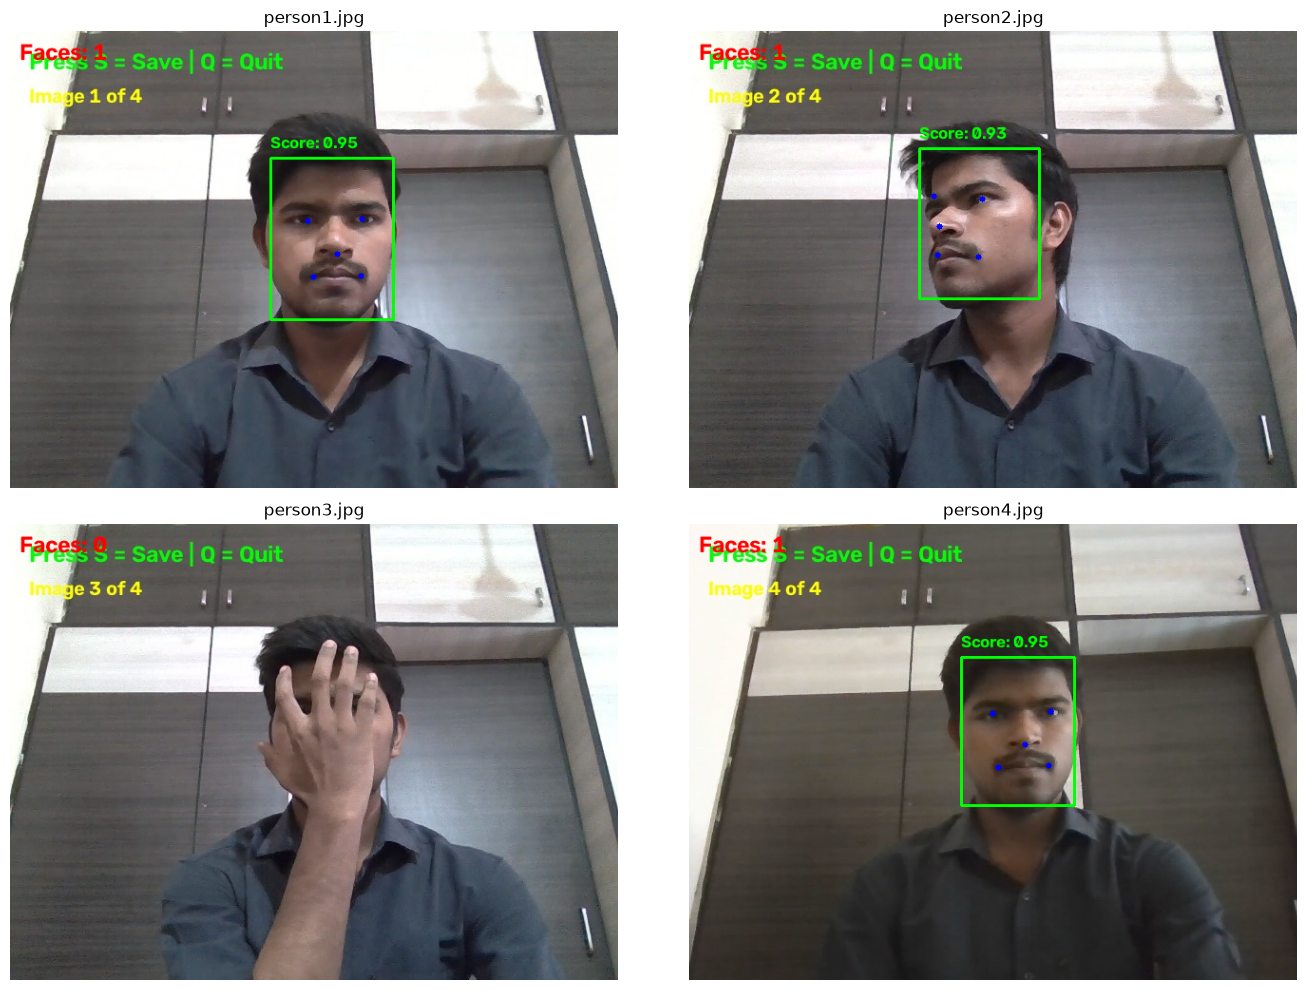

In [8]:
# Create a 2 x 2 figure
plt.figure(figsize=(14, 10))

# Display each result image
for i, (image_name, image) in enumerate(result_images):

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 2, i + 1)
    plt.imshow(image_rgb)
    plt.title(image_name)
    plt.axis("off")

# Adjust spacing
plt.tight_layout()
plt.show()

## Display detection information

In [9]:
print("Detection Details")
print("=" * 70)

# Display information for every detected face
for result in detection_results:

    print("Image:", result["image"])
    print("Face:", result["face_number"])

    print(
        "Bounding Box:",
        "(",
        result["x"],
        ",",
        result["y"],
        ",",
        result["width"],
        ",",
        result["height"],
        ")"
    )

    print("Confidence:", result["confidence"])
    print("-" * 70)

Detection Details
Image: person1.jpg
Face: 1
Bounding Box: ( 274 , 133 , 129 , 170 )
Confidence: 0.954
----------------------------------------------------------------------
Image: person2.jpg
Face: 1
Bounding Box: ( 242 , 123 , 126 , 158 )
Confidence: 0.934
----------------------------------------------------------------------
Image: person4.jpg
Face: 1
Bounding Box: ( 286 , 140 , 119 , 156 )
Confidence: 0.948
----------------------------------------------------------------------


## Display the final results

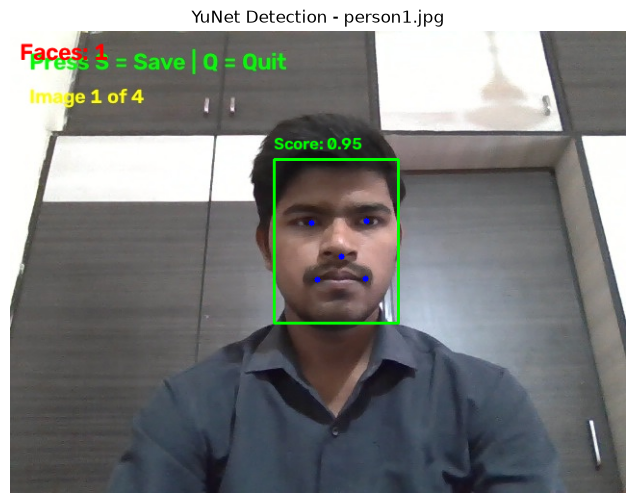

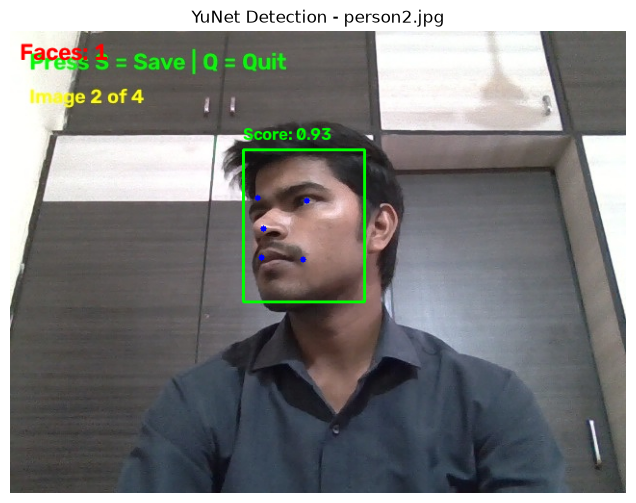

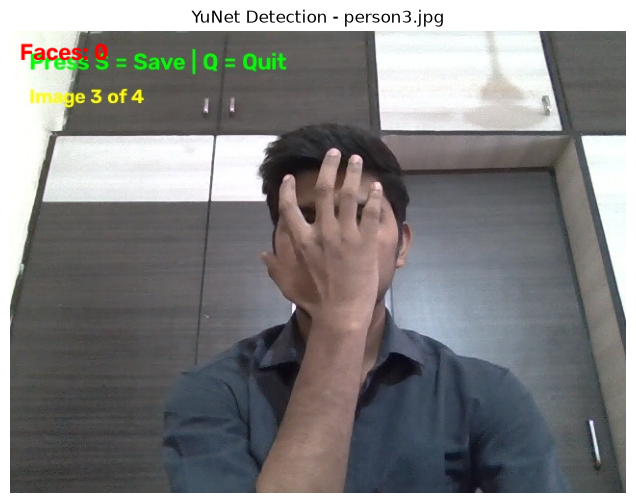

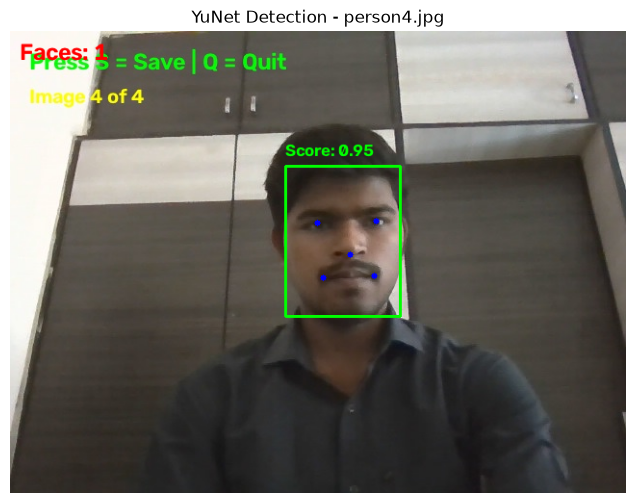

In [10]:
# Display every detected image separately
for image_name, image in result_images:

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(8, 6))
    plt.imshow(image_rgb)
    plt.title("YuNet Detection - " + image_name)
    plt.axis("off")
    plt.show()

## 3.3 Real-Time YuNet Detection

In [ ]:
cap = cv2.VideoCapture(0)


# Check whether the webcam opened successfully
if not cap.isOpened():
    print("Webcam could not be opened.")

else:
    print("Webcam started.")
    print("Press Q to stop the webcam.")


    # Record starting time
    start_time = time.time()

    # Count processed frames
    frame_count = 0

    # Start the webcam loop
    while True:

        # Read one webcam frame
        ret, frame = cap.read()

        # Stop if a frame was not received
        if not ret:
            break

        # Set detector input size
        detector.setInputSize((frame.shape[1], frame.shape[0]))

        # Detect faces
        _, faces = detector.detect(frame)


        # Draw face detections
        if faces is not None:

            # Process every detected face
            for face in faces:

                # Get face coordinates
                x = int(face[0])
                y = int(face[1])
                w = int(face[2])
                h = int(face[3])

                # Draw the face box
                cv2.rectangle(
                    frame,
                    (x, y),
                    (x + w, y + h),
                    (0, 255, 0),
                    2
                )

                # Get 5 facial landmarks
                landmark_points = face[4:14].reshape(
                    5, 2
                ).astype(int)

                # Draw landmarks
                for point in landmark_points:

                    cv2.circle(
                        frame,
                        tuple(point),
                        3,
                        (255, 0, 0),
                        -1
                    )

                # Draw confidence score
                cv2.putText(
                    frame,
                    f"{face[14]:.2f}",
                    (x, max(20, y - 10)),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.6,
                    (0, 255, 0),
                    2
                )


        # Increase frame count
        frame_count = frame_count + 1
        elapsed_time = time.time() - start_time
        fps = frame_count / elapsed_time

        # Display FPS on webcam
        cv2.putText(
            frame,
            f"FPS: {fps:.2f}",
            (10, 30),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (0, 255, 255),
            2
        )

        cv2.imshow("YuNet Face Detection",frame)

        # Press Q to stop
        if cv2.waitKey(1) & 0xFF == ord("q"):
            break

    cap.release()

    # Close OpenCV windows
    cv2.destroyAllWindows()
    cv2.waitKey(1)

    print("Camera stopped.")
    print("Average FPS:", round(fps, 2))

Webcam started.
Press Q to stop the webcam.
Camera stopped.
Average FPS: 28.75


# 3.4 YuNet Threshold Experiment
## Load one test image

In [15]:
# Path of test image
image_path = "data/images/person1.jpg"

img = cv2.imread(image_path)
img_h = img.shape[0]
img_w = img.shape[1]

# Display image size
print("Image Width:", img_w)
print("Image Height:", img_h)

Image Width: 640
Image Height: 480


In [16]:
# Different score thresholds
thresholds = [0.5, 0.7, 0.9]

threshold_results = []
face_counts = []

# Run detection for every threshold
for threshold in thresholds:

    # Create YuNet detector
    detector = cv2.FaceDetectorYN_create(
        "data/models/face_detection_yunet_2023mar.onnx",
        "",
        (img_w, img_h),
        threshold
    )

    detector.setInputSize((img_w, img_h))

    # Detect faces
    _, faces = detector.detect(img)

    # Make a copy of original image
    output = img.copy()
    
    count = 0

    # Check if faces were detected
    if faces is not None:
        for face in faces:
            count += 1

            x = int(face[0])
            y = int(face[1])
            w = int(face[2])
            h = int(face[3])

            confidence = float(face[14])

            # Draw bounding box
            cv2.rectangle(
                output,
                (x, y),
                (x + w, y + h),
                (0, 255, 0),
                2
            )

            # Display confidence
            cv2.putText(
                output,
                "Score: " + str(round(confidence, 2)),
                (x, max(y - 10, 20)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (0, 255, 0),
                2
            )

    # Store number of faces
    face_counts.append(count)

    # Store image and threshold
    threshold_results.append((threshold, output))

    # Print result
    print(
        "Threshold:",
        threshold,
        "| Faces detected:",
        count
    )

Threshold: 0.5 | Faces detected: 1
Threshold: 0.7 | Faces detected: 1
Threshold: 0.9 | Faces detected: 1


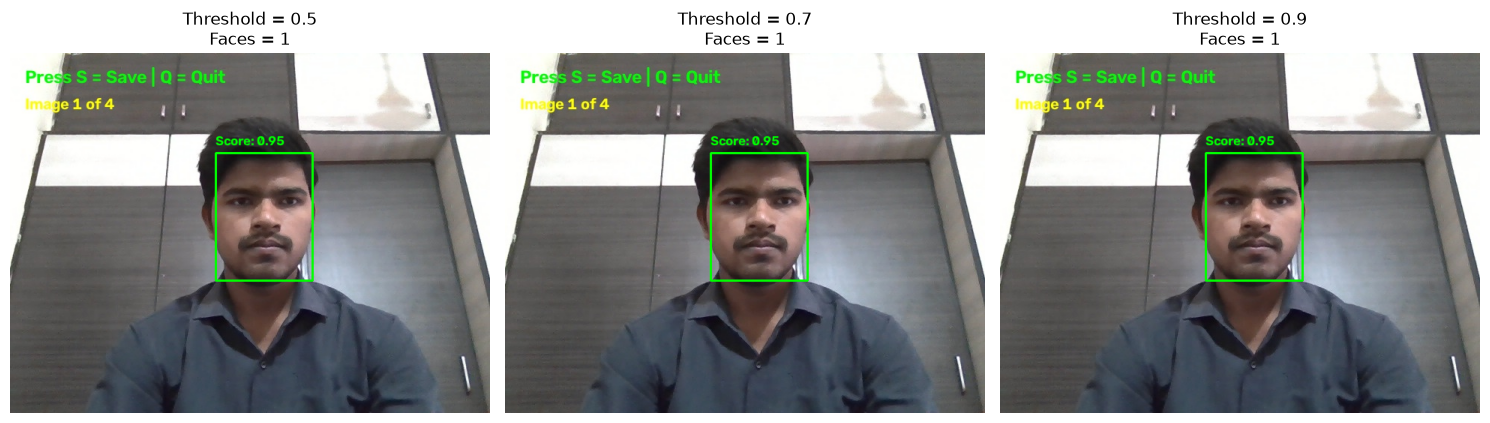

In [17]:
plt.figure(figsize=(15, 5))

for i, (threshold, output) in enumerate(threshold_results):

    output_rgb = cv2.cvtColor(output, cv2.COLOR_BGR2RGB)

    plt.subplot(1, 3, i + 1)

    plt.imshow(output_rgb)
    plt.title(
        "Threshold = " +
        str(threshold) +
        "\nFaces = " +
        str(face_counts[i])
    )

    # Hide axis
    plt.axis("off")

plt.tight_layout()
plt.show()

# Face Privacy Blur
### Now we will use the detected face boxes and blur only the face area.
## Detect faces using threshold 0.9

In [18]:
threshold = 0.9

detector = cv2.FaceDetectorYN_create(
    "data/models/face_detection_yunet_2023mar.onnx",
    "",
    (img_w, img_h),
    threshold
)
detector.setInputSize((img_w, img_h))

_, faces = detector.detect(img)

blurred_image = img.copy()

In [19]:
if faces is not None:

    for face in faces:

        x = int(face[0])
        y = int(face[1])
        w = int(face[2])
        h = int(face[3])

        x1 = max(0, x)
        y1 = max(0, y)

        x2 = min(img_w, x + w)
        y2 = min(img_h, y + h)

        # Extract face region
        face_region = blurred_image[y1:y2, x1:x2]

        # Apply Gaussian blur
        blurred_region = cv2.GaussianBlur(
            face_region,
            (51, 51),
            0
        )

        # Put blurred region back
        blurred_image[y1:y2, x1:x2] = blurred_region

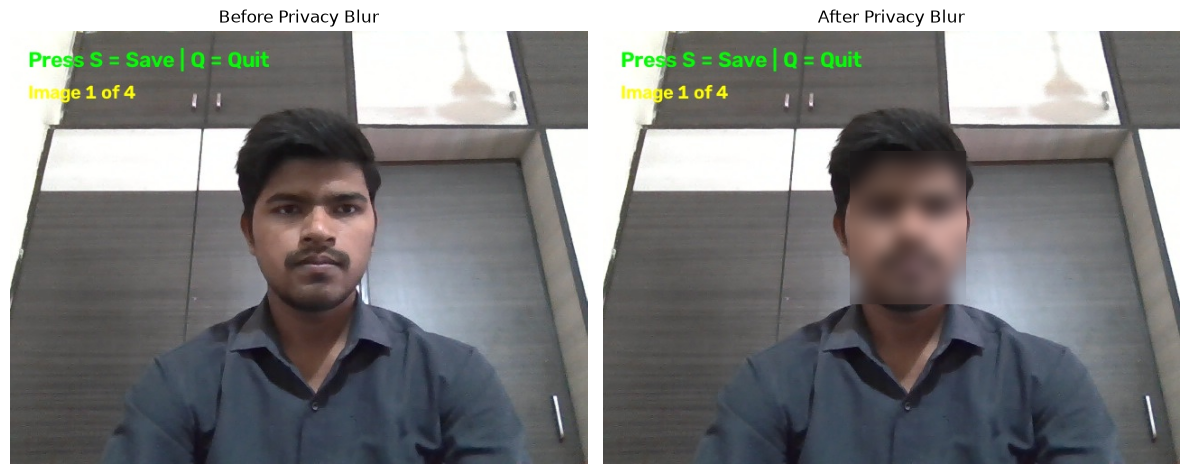

In [20]:
original_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

blurred_rgb = cv2.cvtColor(
    blurred_image,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(12, 5))

# Original image
plt.subplot(1, 2, 1)
plt.imshow(original_rgb)
plt.title("Before Privacy Blur")
plt.axis("off")

# Blurred image
plt.subplot(1, 2, 2)
plt.imshow(blurred_rgb)
plt.title("After Privacy Blur")
plt.axis("off")

plt.tight_layout()

plt.show()

In [21]:
output_path = "outputs/privacy_blurred_person1.jpg"

cv2.imwrite(output_path, blurred_image)

# Print saved location
print("Privacy blurred image saved at:")
print(output_path)

Privacy blurred image saved at:
outputs/privacy_blurred_person1.jpg


# 3.5 WHY YuNet? 

### Why YuNet?

YuNet is a compact and modern CNN-based face detector designed for fast face detection. It is available in OpenCV through `cv2.FaceDetectorYN`, making it convenient to use in computer vision applications.

YuNet is lightweight, so it can perform face detection efficiently in real-time applications such as webcam-based systems. It is trained using diverse, in-the-wild face data, which helps it handle different face conditions such as different poses, lighting conditions, partial occlusion, and relatively small or blurry faces.

Another important advantage of YuNet is that it provides both a face bounding box and **5 facial landmarks** in a single detection result. The five landmarks represent the two eyes, nose, and two mouth corners. This makes YuNet useful for applications that need both face detection and basic facial alignment information.

### Score Threshold

YuNet uses a `score_threshold` to decide whether a detected face should be accepted.

- A **lower threshold**, such as `0.5`, accepts more detections. It may detect weaker faces, but it can also increase false positives.
- A **medium threshold**, such as `0.7`, provides a balance between detecting faces and rejecting weak detections.
- A **higher threshold**, such as `0.9`, is more strict. It can reduce false positives, but some difficult or low-confidence faces may be missed.

Therefore, the threshold creates a trade-off between **missed detections (false negatives)** and **false positives**.

### Threshold Choice for Different Applications

For a **real-time security camera**, I would choose a threshold around **0.7** as a starting point. A security system needs to detect faces reliably, including faces that may be partially hidden or captured under difficult lighting. The final threshold should be selected after testing on representative camera footage.

For an **offline photo-tagging application**, I would choose a higher threshold such as **0.9** when avoiding incorrect face detections is more important than detecting every difficult face. Since photo tagging can be reviewed or processed again offline, a stricter threshold can help reduce unwanted detections.

### Conclusion

YuNet is useful because it combines:

- Lightweight and fast face detection
- CNN-based face detection
- Good handling of varied face conditions
- Bounding-box detection
- 5-point facial landmarks
- Adjustable confidence threshold
- Real-time performance

In this practical, YuNet was used for static-image detection, real-time webcam detection, threshold experiments, and a simple privacy-blur application.

# TASK 4 : YOLOv8 Object Detection
## Import YOLO

In [22]:
from ultralytics import YOLO

# Load YOLOv8 Nano model
model = YOLO(
    "yolov8n.pt"
)

# Display model information
model.info()

YOLOv8n summary: 129 layers, 3,157,200 parameters, 0 gradients, 8.9 GFLOPs


(129, 3157200, 0, 8.8550912)

## Define static images

In [23]:
# List of test images
image_paths = [
    "data/images/yolo_test1.jpg",
    "data/images/yolo_test2.jpg",
    "data/images/yolo_test3.jpg"
]

# Print image paths
for path in image_paths:
    print(path)

data/images/yolo_test1.jpg
data/images/yolo_test2.jpg
data/images/yolo_test3.jpg


## Run YOLOv8 on all images

In [24]:
# Store detection results
all_results = []

for image_path in image_paths:

    results = model(image_path)

    result = results[0]

    plotted_image = result.plot()

    all_results.append(
        (image_path, plotted_image)
    )

    print("Processed:", image_path)


image 1/1 d:\Data\Deep Learning\DL_PR3\data\images\yolo_test1.jpg: 448x640 1 person, 4 cars, 1 bed, 105.2ms
Speed: 8.3ms preprocess, 105.2ms inference, 1.9ms postprocess per image at shape (1, 3, 448, 640)
Processed: data/images/yolo_test1.jpg

image 1/1 d:\Data\Deep Learning\DL_PR3\data\images\yolo_test2.jpg: 480x640 1 person, 2 couchs, 1 potted plant, 1 cell phone, 112.3ms
Speed: 3.6ms preprocess, 112.3ms inference, 1.0ms postprocess per image at shape (1, 3, 480, 640)
Processed: data/images/yolo_test2.jpg

image 1/1 d:\Data\Deep Learning\DL_PR3\data\images\yolo_test3.jpg: 352x640 8 persons, 4 cups, 3 chairs, 1 potted plant, 3 dining tables, 2 laptops, 2 cell phones, 108.2ms
Speed: 2.5ms preprocess, 108.2ms inference, 1.1ms postprocess per image at shape (1, 3, 352, 640)
Processed: data/images/yolo_test3.jpg


## Display the results

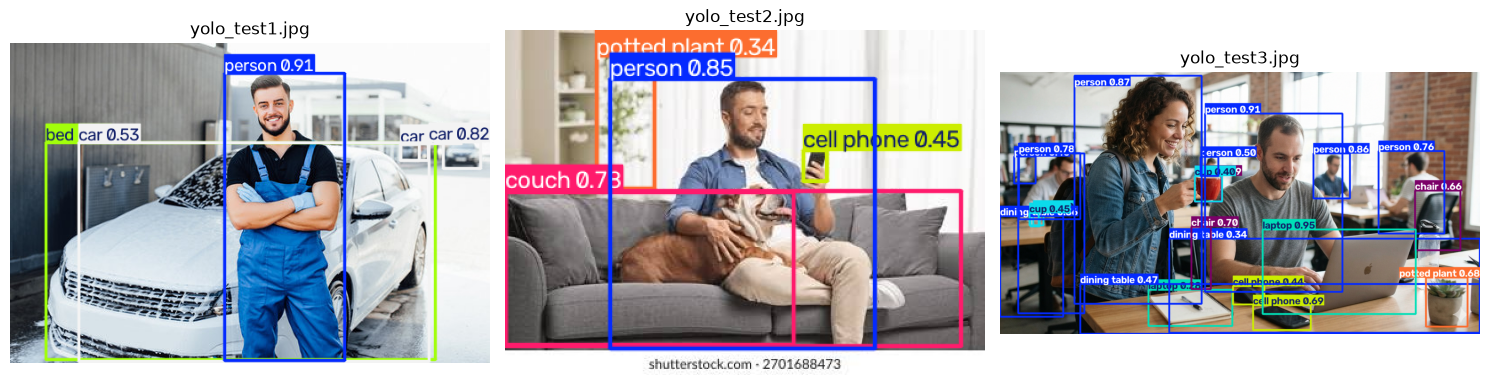

In [25]:
# Create figure
plt.figure(figsize=(15, 5))

# Display every result
for i, (image_path, plotted_image) in enumerate(all_results):

    # Convert BGR to RGB
    plotted_rgb = cv2.cvtColor(
        plotted_image,
        cv2.COLOR_BGR2RGB
    )

    # Create subplot
    plt.subplot(1, len(all_results), i + 1)

    # Display image
    plt.imshow(plotted_rgb)

    # Display image name
    plt.title(image_path.split("/")[-1])

    # Hide axis
    plt.axis("off")

# Adjust layout
plt.tight_layout()

# Show results
plt.show()

In [26]:
os.makedirs("outputs", exist_ok=True)

# Save every detection result
for image_path, plotted_image in all_results:

    image_name = os.path.basename(image_path)

    output_path = "outputs/yolo_" + image_name

    cv2.imwrite(output_path, plotted_image)

    # Print saved location
    print("Saved:", output_path)

Saved: outputs/yolo_yolo_test1.jpg
Saved: outputs/yolo_yolo_test2.jpg
Saved: outputs/yolo_yolo_test3.jpg



image 1/1 d:\Data\Deep Learning\DL_PR3\data\images\yolo_test1.jpg: 448x640 1 person, 4 cars, 1 bed, 85.3ms
Speed: 4.5ms preprocess, 85.3ms inference, 1.5ms postprocess per image at shape (1, 3, 448, 640)


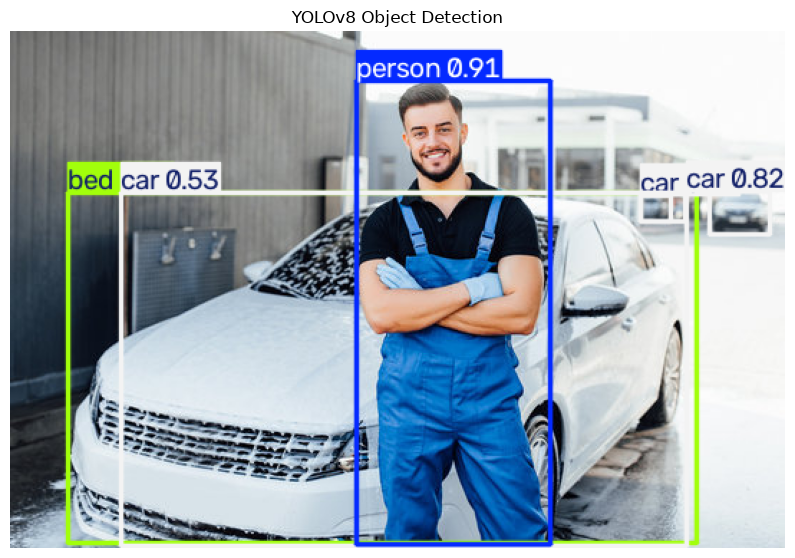

In [27]:
# Image path
image_path = "data/images/yolo_test1.jpg"

# Run YOLOv8 on the image
results = model(image_path)

# Plot the detection result
result_image = results[0].plot()

# Convert BGR to RGB
result_image = cv2.cvtColor(
    result_image,
    cv2.COLOR_BGR2RGB
)

# Display the result
plt.figure(figsize=(10, 7))

# Show image
plt.imshow(result_image)

# Add title
plt.title("YOLOv8 Object Detection")

# Hide axes
plt.axis("off")

# Display image
plt.show()


image 1/1 d:\Data\Deep Learning\DL_PR3\data\images\yolo_test1.jpg: 448x640 1 person, 4 cars, 1 bed, 81.0ms
Speed: 2.5ms preprocess, 81.0ms inference, 1.1ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 d:\Data\Deep Learning\DL_PR3\data\images\yolo_test2.jpg: 480x640 1 person, 2 couchs, 1 potted plant, 1 cell phone, 47.5ms
Speed: 2.2ms preprocess, 47.5ms inference, 0.7ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 d:\Data\Deep Learning\DL_PR3\data\images\yolo_test3.jpg: 352x640 8 persons, 4 cups, 3 chairs, 1 potted plant, 3 dining tables, 2 laptops, 2 cell phones, 31.8ms
Speed: 1.9ms preprocess, 31.8ms inference, 0.9ms postprocess per image at shape (1, 3, 352, 640)


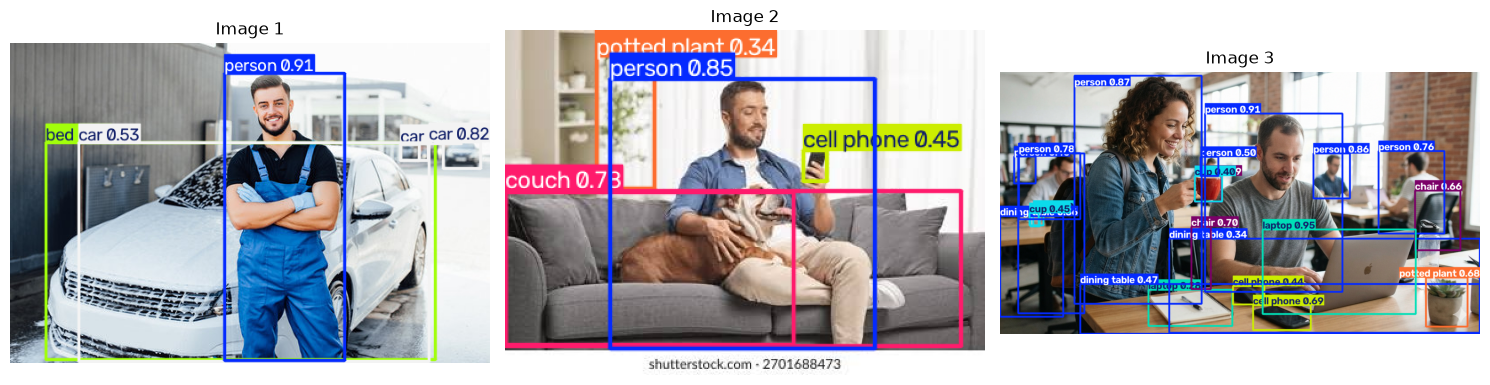

In [28]:
# List of images
image_paths = [
    "data/images/yolo_test1.jpg",
    "data/images/yolo_test2.jpg",
    "data/images/yolo_test3.jpg"
]

# Create figure
plt.figure(figsize=(15, 5))

# Process each image
for i, image_path in enumerate(image_paths):

    # Run YOLO detection
    results = model(image_path)

    # Get plotted result
    result_image = results[0].plot()

    # Convert BGR to RGB
    result_image = cv2.cvtColor(
        result_image,
        cv2.COLOR_BGR2RGB
    )

    # Create subplot
    plt.subplot(1, 3, i + 1)

    # Display image
    plt.imshow(result_image)

    # Display image name
    plt.title("Image " + str(i + 1))

    # Hide axes
    plt.axis("off")

# Adjust spacing
plt.tight_layout()

# Show all results
plt.show()

In [29]:
# List of images
image_paths = [
    "data/images/yolo_test1.jpg",
    "data/images/yolo_test2.jpg",
    "data/images/yolo_test3.jpg"
]

# Process each image
for image_path in image_paths:

    # Run YOLO
    results = model(image_path)

    # Get first result
    yolo_result = results[0]

    # Get class IDs
    class_ids = yolo_result.boxes.cls.cpu().numpy()

    # Get confidence scores
    confidence_scores = yolo_result.boxes.conf.cpu().numpy()

    # Print image name
    print("\nImage:", image_path)

    # Loop through detections
    for i in range(len(class_ids)):

        # Get class ID
        class_id = int(class_ids[i])

        # Get class name
        class_name = model.names[class_id]

        # Get confidence
        confidence = float(confidence_scores[i])

        # Print result
        print(
            "Object:",
            class_name,
            "| Confidence:",
            round(confidence, 2)
        )


image 1/1 d:\Data\Deep Learning\DL_PR3\data\images\yolo_test1.jpg: 448x640 1 person, 4 cars, 1 bed, 69.9ms
Speed: 2.0ms preprocess, 69.9ms inference, 0.9ms postprocess per image at shape (1, 3, 448, 640)

Image: data/images/yolo_test1.jpg
Object: person | Confidence: 0.91
Object: car | Confidence: 0.82
Object: car | Confidence: 0.53
Object: car | Confidence: 0.39
Object: bed | Confidence: 0.35
Object: car | Confidence: 0.29

image 1/1 d:\Data\Deep Learning\DL_PR3\data\images\yolo_test2.jpg: 480x640 1 person, 2 couchs, 1 potted plant, 1 cell phone, 45.1ms
Speed: 2.0ms preprocess, 45.1ms inference, 1.1ms postprocess per image at shape (1, 3, 480, 640)

Image: data/images/yolo_test2.jpg
Object: person | Confidence: 0.85
Object: couch | Confidence: 0.78
Object: couch | Confidence: 0.65
Object: cell phone | Confidence: 0.45
Object: potted plant | Confidence: 0.34

image 1/1 d:\Data\Deep Learning\DL_PR3\data\images\yolo_test3.jpg: 352x640 8 persons, 4 cups, 3 chairs, 1 potted plant, 3 dinin

## Start webcam and real-time detection

In [30]:
# Open webcam
cap = cv2.VideoCapture(0)

# Check if webcam opened
if not cap.isOpened():
    print("Camera could not be opened")

else:

    print("Camera started")
    print("Press Q to stop")

    # Start time
    start_time = time.time()

    # Frame counter
    frame_count = 0

    # Start webcam loop
    while True:

        # Read one frame
        ret, frame = cap.read()

        # Stop if frame is not received
        if not ret:
            print("Could not read frame")
            break

        # Run YOLO detection on current frame
        results = model(
            frame,
            verbose=False
        )

        # Plot detection results
        annotated_frame = results[0].plot()

        # Increase frame count
        frame_count += 1

        # Calculate elapsed time
        elapsed_time = time.time() - start_time

        # Calculate FPS
        fps = frame_count / elapsed_time

        # Display FPS
        cv2.putText(
            annotated_frame,
            "FPS: " + str(round(fps, 2)),
            (10, 30),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (0, 255, 0),
            2
        )

        # Display instruction
        cv2.putText(
            annotated_frame,
            "Press Q to Quit",
            (10, 60),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (255, 255, 255),
            2
        )

        # Show annotated webcam
        cv2.imshow(
            "YOLOv8 Real-Time Detection",
            annotated_frame
        )

        # Read keyboard input
        key = cv2.waitKey(1) & 0xFF

        # Press Q to quit
        if key == ord("q") or key == ord("Q"):
            print("Q pressed. Stopping camera...")
            break

    # Release webcam
    cap.release()

    # Close OpenCV windows
    cv2.destroyAllWindows()

    # Make sure windows are closed
    cv2.waitKey(1)

    # Print final results
    print()
    print("Total Frames:", frame_count)
    print("Average FPS:", round(fps, 2))

Camera started
Press Q to stop
Q pressed. Stopping camera...

Total Frames: 252
Average FPS: 14.95


# 4.3 Confidence & IoU Threshold Tuning

For this task, we will test:

* Confidence: 0.25, 0.5, 0.75
* IoU: 0.3, 0.5, 0.7
* Count the retained bounding boxes.
* Plot the results.
* Display one example for comparison.

Important: In YOLO, the iou parameter controls the IoU threshold used during Non-Maximum Suppression (NMS). It does not create duplicate boxes by itself. A lower NMS IoU threshold is generally more aggressive and can remove overlapping boxes more easily.


## Test confidence thresholds

In [31]:
# Confidence thresholds
conf_values = [0.25, 0.5, 0.75]

conf_results = []

# Run detection for each confidence value
for conf in conf_values:
    results = model(
        image_path,
        conf=conf,
        iou=0.5
    )

    yolo_result = results[0]

    box_count = len(yolo_result.boxes)

    conf_results.append({
        "Confidence": conf,
        "Boxes": box_count
    })
    print(
        "Confidence:",
        conf,
        "| Retained Boxes:",
        box_count
    )


image 1/1 d:\Data\Deep Learning\DL_PR3\data\images\yolo_test3.jpg: 352x640 8 persons, 3 cups, 3 chairs, 1 potted plant, 3 dining tables, 2 laptops, 2 cell phones, 128.4ms
Speed: 2.6ms preprocess, 128.4ms inference, 1.1ms postprocess per image at shape (1, 3, 352, 640)
Confidence: 0.25 | Retained Boxes: 22

image 1/1 d:\Data\Deep Learning\DL_PR3\data\images\yolo_test3.jpg: 352x640 5 persons, 2 chairs, 1 potted plant, 1 laptop, 1 cell phone, 34.9ms
Speed: 1.7ms preprocess, 34.9ms inference, 0.8ms postprocess per image at shape (1, 3, 352, 640)
Confidence: 0.5 | Retained Boxes: 10

image 1/1 d:\Data\Deep Learning\DL_PR3\data\images\yolo_test3.jpg: 352x640 5 persons, 1 laptop, 44.9ms
Speed: 2.7ms preprocess, 44.9ms inference, 0.8ms postprocess per image at shape (1, 3, 352, 640)
Confidence: 0.75 | Retained Boxes: 6


## Plot confidence results

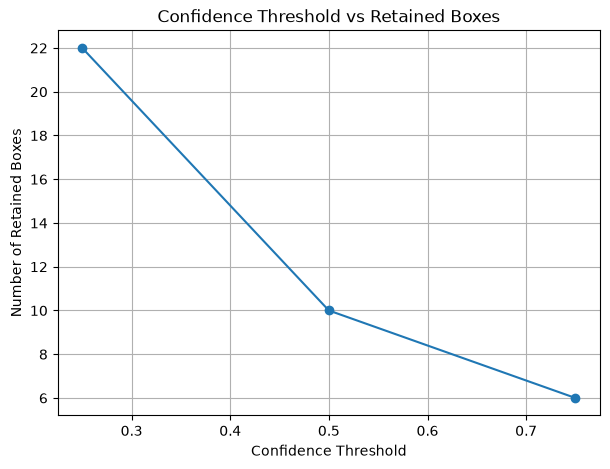

In [32]:
# Convert results into DataFrame
conf_df = pd.DataFrame(conf_results)

plt.figure(figsize=(7, 5))
plt.plot(
    conf_df["Confidence"],
    conf_df["Boxes"],
    marker="o"
)

# Add title
plt.title("Confidence Threshold vs Retained Boxes")

plt.xlabel("Confidence Threshold")
plt.ylabel("Number of Retained Boxes")
plt.grid(True)
plt.show()

### Observation

Generally, increasing the confidence threshold means that only detections with higher confidence are retained, so the number of boxes may decrease.

## Markdown

The confidence threshold controls which detections are retained based on their confidence scores. Increasing the confidence threshold from 0.25 to 0.75 generally removes lower-confidence detections and can reduce the number of retained boxes.

## Test IoU thresholds

In [33]:
# IoU thresholds
iou_values = [0.3, 0.5, 0.7]

iou_results = []

for iou in iou_values:

    # Run YOLO
    results = model(
        image_path,
        conf=0.25,
        iou=iou
    )

    yolo_result = results[0]
    box_count = len(yolo_result.boxes)

    iou_results.append({
        "IoU": iou,
        "Boxes": box_count
    })

    print(
        "IoU:",
        iou,
        "| Retained Boxes:",
        box_count
    )


image 1/1 d:\Data\Deep Learning\DL_PR3\data\images\yolo_test3.jpg: 352x640 7 persons, 3 cups, 3 chairs, 1 potted plant, 2 dining tables, 2 laptops, 2 cell phones, 60.2ms
Speed: 3.4ms preprocess, 60.2ms inference, 1.2ms postprocess per image at shape (1, 3, 352, 640)
IoU: 0.3 | Retained Boxes: 20

image 1/1 d:\Data\Deep Learning\DL_PR3\data\images\yolo_test3.jpg: 352x640 8 persons, 3 cups, 3 chairs, 1 potted plant, 3 dining tables, 2 laptops, 2 cell phones, 36.5ms
Speed: 1.9ms preprocess, 36.5ms inference, 0.8ms postprocess per image at shape (1, 3, 352, 640)
IoU: 0.5 | Retained Boxes: 22

image 1/1 d:\Data\Deep Learning\DL_PR3\data\images\yolo_test3.jpg: 352x640 8 persons, 4 cups, 3 chairs, 1 potted plant, 3 dining tables, 2 laptops, 2 cell phones, 32.4ms
Speed: 2.7ms preprocess, 32.4ms inference, 1.7ms postprocess per image at shape (1, 3, 352, 640)
IoU: 0.7 | Retained Boxes: 23


## Plot IoU results

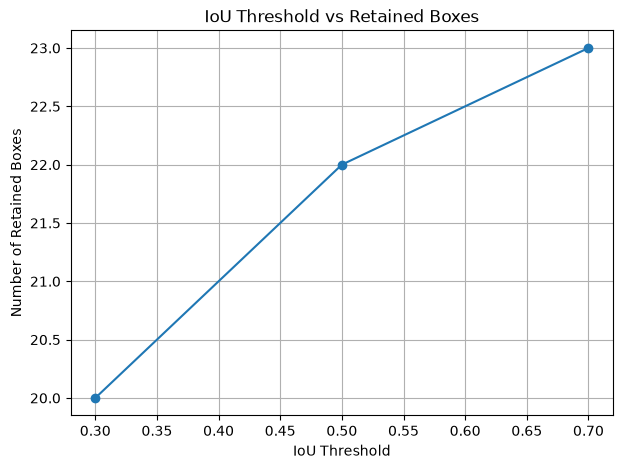

In [34]:
# Convert to DataFrame
iou_df = pd.DataFrame(iou_results)

plt.figure(figsize=(7, 5))

plt.plot(
    iou_df["IoU"],
    iou_df["Boxes"],
    marker="o"
)
plt.title("IoU Threshold vs Retained Boxes")

plt.xlabel("IoU Threshold")

plt.ylabel("Number of Retained Boxes")
plt.grid(True)
plt.show()

## Compare IoU = 0.3 and IoU = 0.7

In [35]:
# Run YOLO with IoU = 0.3
result_low_iou = model(
    image_path,
    conf=0.25,
    iou=0.3
)[0]

# Run YOLO with IoU = 0.7
result_high_iou = model(
    image_path,
    conf=0.25,
    iou=0.7
)[0]

low_iou_image = result_low_iou.plot()

high_iou_image = result_high_iou.plot()


image 1/1 d:\Data\Deep Learning\DL_PR3\data\images\yolo_test3.jpg: 352x640 7 persons, 3 cups, 3 chairs, 1 potted plant, 2 dining tables, 2 laptops, 2 cell phones, 70.5ms
Speed: 4.8ms preprocess, 70.5ms inference, 1.2ms postprocess per image at shape (1, 3, 352, 640)

image 1/1 d:\Data\Deep Learning\DL_PR3\data\images\yolo_test3.jpg: 352x640 8 persons, 4 cups, 3 chairs, 1 potted plant, 3 dining tables, 2 laptops, 2 cell phones, 81.8ms
Speed: 5.8ms preprocess, 81.8ms inference, 1.1ms postprocess per image at shape (1, 3, 352, 640)


## Display both images

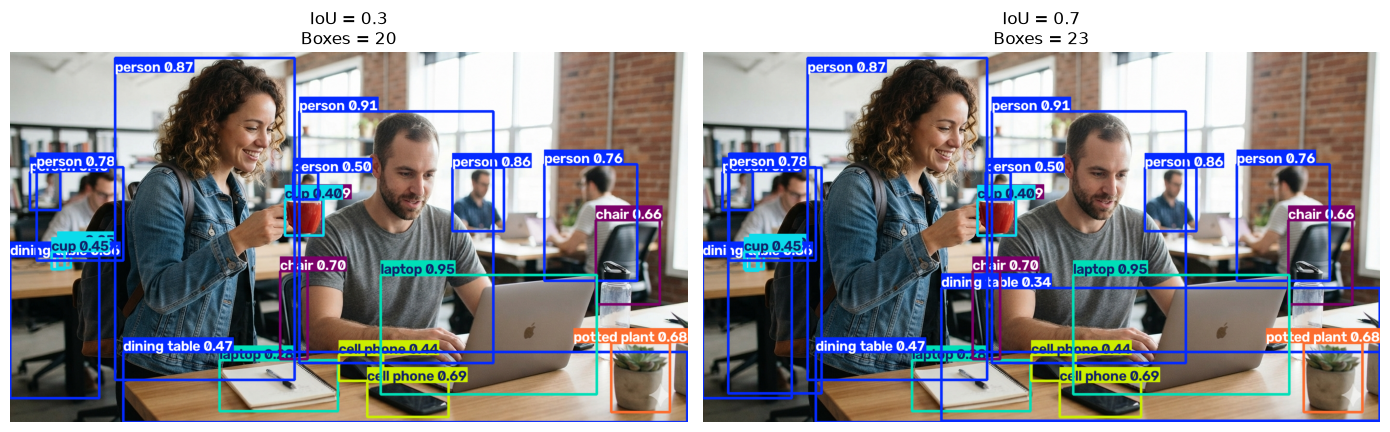

In [36]:
# Create figure
plt.figure(figsize=(14, 6))

# Low IoU
plt.subplot(1, 2, 1)
plt.imshow(low_iou_image[:, :, ::-1])
plt.title(
    "IoU = 0.3\nBoxes = " +
    str(len(result_low_iou.boxes))
)
plt.axis("off")

# High IoU
plt.subplot(1, 2, 2)
plt.imshow(high_iou_image[:, :, ::-1])
plt.title(
    "IoU = 0.7\nBoxes = " +
    str(len(result_high_iou.boxes))
)
plt.axis("off")

plt.tight_layout()

plt.show()

## Observation

The IoU threshold is used during Non-Maximum Suppression (NMS). NMS removes overlapping detections when they represent the same object. A lower IoU threshold makes NMS more aggressive, while a higher IoU threshold allows more overlapping boxes to remain.

Therefore, confidence threshold mainly controls the quality of accepted detections, while IoU threshold controls how overlapping detections are handled during NMS. The exact number of retained boxes depends on the input image and detected objects.

## 4.4 : Per-Class Detection Summary

In [37]:
# Import Counter for counting objects
from collections import Counter

# Store all test image paths
image_paths = [
    "data/images/yolo_test1.jpg",
    "data/images/yolo_test2.jpg",
    "data/images/yolo_test3.jpg"
]


# Create an empty Counter
class_counts = Counter()


# Run YOLO on every image
for image_path in image_paths:

    results = model(image_path, conf=0.25)

    yolo_result = results[0]

    class_ids = yolo_result.boxes.cls.cpu().numpy()

    for class_id in class_ids:

        class_id = int(class_id)

        class_name = model.names[class_id]

        class_counts[class_name] += 1


# Print the final detection summary
print("Per-Class Detection Summary")
print("---------------------------")

for class_name, count in class_counts.items():

    # Print class and number of detections
    print(class_name, ":", count)


image 1/1 d:\Data\Deep Learning\DL_PR3\data\images\yolo_test1.jpg: 448x640 1 person, 4 cars, 1 bed, 102.7ms
Speed: 2.5ms preprocess, 102.7ms inference, 1.7ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 d:\Data\Deep Learning\DL_PR3\data\images\yolo_test2.jpg: 480x640 1 person, 2 couchs, 1 potted plant, 1 cell phone, 50.5ms
Speed: 1.9ms preprocess, 50.5ms inference, 0.8ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 d:\Data\Deep Learning\DL_PR3\data\images\yolo_test3.jpg: 352x640 8 persons, 4 cups, 3 chairs, 1 potted plant, 3 dining tables, 2 laptops, 2 cell phones, 47.7ms
Speed: 2.1ms preprocess, 47.7ms inference, 1.0ms postprocess per image at shape (1, 3, 352, 640)
Per-Class Detection Summary
---------------------------
person : 10
car : 4
bed : 1
couch : 2
cell phone : 3
potted plant : 2
laptop : 2
chair : 3
dining table : 3
cup : 4


## Plot the bar chart

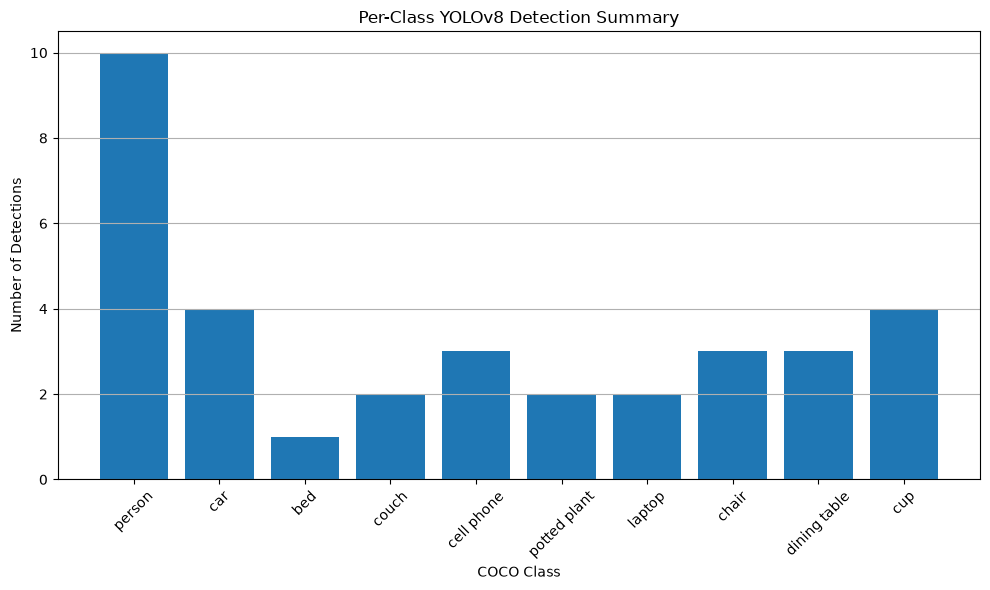

In [39]:
class_names = list(class_counts.keys())

counts = list(class_counts.values())

plt.figure(figsize=(10, 6))
plt.bar(class_names, counts)
plt.title("Per-Class YOLOv8 Detection Summary")

plt.xlabel("COCO Class")

plt.ylabel("Number of Detections")

plt.xticks(rotation=45)

plt.grid(axis="y")

# Display the chart
plt.tight_layout()
plt.show()

### Observation

YOLOv8 detected several COCO classes across the test images. 
The number of detections varied depending on the objects present in each image.

Some objects may have been missed or incorrectly classified. Possible reasons include:

1. **Occlusion:** An object may be partially hidden behind another object.
2. **Small object size:** Very small objects contain fewer visual features.
3. **Unusual angle:** Objects viewed from uncommon angles can be harder to recognize.
4. **Poor lighting:** Dark or overexposed images can reduce detection accuracy.
5. **Object similarity:** Similar-looking objects may sometimes be confused.
6. **Low image quality:** Blur or low resolution can make detection difficult.

Overall, the per-class summary helps identify which COCO classes were detected most frequently and which classes may require better image conditions or a more suitable model.

# 4.5 WHY YOLO generalises 

YOLO is a single-stage object detector. It predicts object bounding boxes and class probabilities in one forward pass and then applies Non-Maximum Suppression to remove duplicate overlapping detections.

The `nano` model is smaller and faster than larger YOLOv8 variants, so it is useful for real-time or low-power applications. The pretrained COCO model can recognise many object categories without manually creating a separate detector for every class.

Detection quality can still fall when objects are very small, heavily occluded, poorly lit, or viewed from unusual angles.

## YOLOv8 Nano

In this project, the pretrained YOLOv8 Nano model (`yolov8n.pt`) is used.

The Nano model is designed to be lightweight and fast.

Its advantages include:

- Small model size
- Faster inference
- Lower computation requirements
- Suitable for real-time applications
- Suitable for systems with limited hardware

However, the smaller model can sacrifice some detection accuracy compared
with larger YOLOv8 variants.

## YOLOv8 Model Variants

YOLOv8 provides several model sizes:

- YOLOv8n — Nano
- YOLOv8s — Small
- YOLOv8m — Medium
- YOLOv8l — Large
- YOLOv8x — Extra Large

Smaller models generally provide greater speed and lower computational cost.

Larger models generally require more computational resources but can provide
higher detection accuracy.

## Conclusion

YOLO is useful for real-time object detection because it combines localisation
and classification within one efficient detection pipeline.

YOLOv8 Nano provides a strong balance between speed and detection capability,
which makes it suitable for webcam and real-time computer-vision applications.

# TASK 5 : Integrated Pipeline & Final Comparison
now we combine:

* Webcam
* YuNet Face Detection
* YOLO Object Detection
* Single Output Frame

In [40]:
yolo_model = YOLO("yolov8n.pt")

cap = cv2.VideoCapture(0)

# Create YuNet detector
face_detector = cv2.FaceDetectorYN_create(
    yunet_model_path,
    "",
    (640, 480),
    0.9
)

# Store previous frame size
previous_size = None

while True:
    ret, frame = cap.read()

    if not ret:
        break

    img_h = frame.shape[0]
    img_w = frame.shape[1]

    current_size = (img_w, img_h)

    # Update YuNet input size if frame size changes
    if current_size != previous_size:

        face_detector.setInputSize(current_size)

        previous_size = current_size


    # Detect faces
    _, faces = face_detector.detect(frame)

    if faces is not None:
        for face in faces:

            x = int(face[0])
            y = int(face[1])
            w = int(face[2])
            h = int(face[3])

            confidence = float(face[14])

            # Draw GREEN rectangle around face
            cv2.rectangle(
                frame,
                (x, y),
                (x + w, y + h),
                (0, 255, 0),
                2
            )


            # Display YuNet confidence
            cv2.putText(
                frame,
                "Face: " + str(round(confidence, 2)),
                (x, max(20, y - 10)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (0, 255, 0),
                2
            )


    # Run YOLO on the current webcam frame
    results = yolo_model(
        frame,
        conf=0.25,
        verbose=False
    )


    # Get YOLO result
    yolo_result = results[0]


    # Check if objects were detected
    if yolo_result.boxes is not None:

        # Process every detected object
        for box in yolo_result.boxes:

            # Get bounding box coordinates
            x1 = int(box.xyxy[0][0])
            y1 = int(box.xyxy[0][1])
            x2 = int(box.xyxy[0][2])
            y2 = int(box.xyxy[0][3])

            class_id = int(box.cls[0])
            class_name = yolo_model.names[class_id]

            confidence = float(box.conf[0])

            # Draw RED rectangle around object
            cv2.rectangle(
                frame,
                (x1, y1),
                (x2, y2),
                (0, 0, 255),
                2
            )

            label = class_name + ": " + str(round(confidence, 2))

            # Display YOLO label
            cv2.putText(
                frame,
                label,
                (x1, max(20, y1 - 10)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (0, 0, 255),
                2
            )


    # =========================================
    # Display information
    # =========================================

    # Display pipeline title
    cv2.putText(
        frame,
        "YuNet + YOLOv8 Unified Pipeline",
        (10, 30),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (255, 255, 255),
        2
    )

    # Display green box explanation
    cv2.putText(
        frame,
        "GREEN = Face",
        (10, 60),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (0, 255, 0),
        2
    )

    # Display red box explanation
    cv2.putText(
        frame,
        "RED = Object",
        (10, 85),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (0, 0, 255),
        2
    )

    # Display quit instruction
    cv2.putText(
        frame,
        "Press Q to Quit",
        (10, 110),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (255, 255, 255),
        2
    )

    # Show the final combined frame
    cv2.imshow(
        "YuNet + YOLOv8",
        frame
    )

    key = cv2.waitKey(1) & 0xFF

    # Quit when Q is pressed
    if key == ord("q") or key == ord("Q"):
        break

cap.release()
cv2.destroyAllWindows()
cv2.waitKey(1)

print("Unified pipeline stopped.")

Unified pipeline stopped.


### Observation

The unified pipeline successfully combines YuNet and YOLOv8 on a single webcam stream.

YuNet detects faces and displays them using green bounding boxes with confidence scores. 
YOLOv8 detects general COCO objects and displays them using red bounding boxes with class labels and confidence scores.

Both detection results are drawn on the same video frame. Therefore, a person's body can be detected by YOLOv8 while the person's face is simultaneously detected by YuNet.

This demonstrates how multiple computer vision models can be combined into a single real-time vision pipeline.

# 5.2 Morphological Pre-Cleaning

We will keep this very simple.

Goal

We will compare:

* Original webcam frame → YuNet + YOLOv8
* Morphological opening frame → YuNet + YOLOv8

Opening = Erosion → Dilation.

In [47]:
# Load YOLO model
yolo_model = YOLO("yolov8n.pt")

# Path of YuNet model
yunet_model_path = "data/models/face_detection_yunet_2023mar.onnx"

cap = cv2.VideoCapture(0)

# Create YuNet detector
face_detector = cv2.FaceDetectorYN_create(
    yunet_model_path,
    "",
    (640, 480),
    0.9
)
previous_size = None

# Create morphological kernel

# Create a small 3x3 rectangular kernel
kernel = cv2.getStructuringElement(
    cv2.MORPH_RECT,
    (3, 3)
)

original_faces = 0
cleaned_faces = 0
original_objects = 0
cleaned_objects = 0

# start webcame
while True:

    # Read frame from webcam
    ret, frame = cap.read()

    # Stop if frame is not received
    if not ret:
        break

    img_h = frame.shape[0]
    img_w = frame.shape[1]

    current_size = (img_w, img_h)

    if current_size != previous_size:
        face_detector.setInputSize(current_size)
        previous_size = current_size


    # Create morphological opening
 
    cleaned_frame = cv2.morphologyEx(
        frame,
        cv2.MORPH_OPEN,
        kernel
    )

    # Detect faces on original frame
    _, original_faces_result = face_detector.detect(frame)
    original_face_count = 0

    if original_faces_result is not None:
        original_face_count = len(original_faces_result)

    # Detect faces on cleaned frame
    _, cleaned_faces_result = face_detector.detect(cleaned_frame)
    cleaned_face_count = 0

    if cleaned_faces_result is not None:

        cleaned_face_count = len(cleaned_faces_result)


    # Run YOLO on original frame
    original_yolo = yolo_model(
        frame,
        conf=0.25,
        verbose=False
    )

    original_result = original_yolo[0]

    original_object_count = len(original_result.boxes)


    # Run YOLO on cleaned frame
    cleaned_yolo = yolo_model(
        cleaned_frame,
        conf=0.25,
        verbose=False
    )
    cleaned_result = cleaned_yolo[0]

    cleaned_object_count = len(cleaned_result.boxes)


    # Save latest counts

    original_faces = original_face_count
    cleaned_faces = cleaned_face_count

    original_objects = original_object_count
    cleaned_objects = cleaned_object_count


    cv2.putText(
        frame,
        "Original - Faces: " + str(original_faces),
        (10, 30),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (0, 255, 0),
        2
    )

    cv2.putText(
        frame,
        "Original - Objects: " + str(original_objects),
        (10, 60),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (0, 0, 255),
        2
    )


    # Add information to cleaned frame
    cv2.putText(
        cleaned_frame,
        "Cleaned - Faces: " + str(cleaned_faces),
        (10, 30),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (0, 255, 0),
        2
    )

    cv2.putText(
        cleaned_frame,
        "Cleaned - Objects: " + str(cleaned_objects),
        (10, 60),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (0, 0, 255),
        2
    )

    cv2.imshow(
        "Original Frame",
        frame
    )

    cv2.imshow(
        "Morphological Opening Frame",
        cleaned_frame
    )

    key = cv2.waitKey(1) & 0xFF
    if key == ord("q") or key == ord("Q"):
        break

cap.release()

# Close windows
cv2.destroyAllWindows()
cv2.waitKey(1)


# --------------------------------
# Print final comparison
# --------------------------------

print("Final Comparison")
print("--------------------------")

print("Original faces :", original_faces)
print("Cleaned faces  :", cleaned_faces)

print("Original objects :", original_objects)
print("Cleaned objects  :", cleaned_objects)

Final Comparison
--------------------------
Original faces : 1
Cleaned faces  : 1
Original objects : 1
Cleaned objects  : 2


## 5.3 FPS Benchmarking

For this task, we will use the same 100 webcam frames for all three tests:

* YuNet face detection only
* YOLOv8 object detection only
* YuNet + YOLOv8 combined pipeline

In [48]:
# Number of frames for testing
total_frames = 100

cap = cv2.VideoCapture(0)

# Check if webcam opened
if not cap.isOpened():

    print("Could not open webcam.")

else:

    print("Webcam opened successfully.")
    print("Starting 100-frame FPS benchmark...")
    print()

ret, frame = cap.read()


# Stop if frame is not available
if not ret:

    print("Could not read webcam frame.")

else:

    # Get frame height
    img_h = frame.shape[0]
    img_w = frame.shape[1]

    # Create YuNet detector
    face_detector = cv2.FaceDetectorYN_create(
        yunet_model_path,
        "",
        (img_w, img_h),
        0.9
    )

    face_detector.setInputSize((img_w, img_h))

    # 1. YuNet Face Detection Only

    print("Testing YuNet...")
    start_time = time.time()

    for i in range(total_frames):
        ret, frame = cap.read()
        if not ret:
            break

        # Run YuNet face detection
        _, faces = face_detector.detect(frame)


    # Calculate total time
    end_time = time.time()
    yunet_time = end_time - start_time
    yunet_fps = total_frames / yunet_time

    print("YuNet FPS:", round(yunet_fps, 2))

    # 2. YOLOv8 Object Detection Only

    print("Testing YOLOv8...")

    start_time = time.time()

    # Process 100 frames
    for i in range(total_frames):
        ret, frame = cap.read()

        if not ret:
            break

        # Run YOLO detection
        results = yolo_model(
            frame,
            conf=0.25,
            verbose=False
        )


    # Calculate total time
    end_time = time.time()
    yolo_time = end_time - start_time
    yolo_fps = total_frames / yolo_time

    print("YOLOv8 FPS:", round(yolo_fps, 2))

    # 3. Full Combined Pipeline

    print("Testing YuNet + YOLOv8...")

    start_time = time.time()

    # Process 100 frames
    for i in range(total_frames):
        ret, frame = cap.read()

        if not ret:
            break

        _, faces = face_detector.detect(frame)

        results = yolo_model(
            frame,
            conf=0.25,
            verbose=False
        )


    # Calculate total time
    end_time = time.time()
    combined_time = end_time - start_time
    combined_fps = total_frames / combined_time

    print("Combined FPS:", round(combined_fps, 2))

cap.release()
cv2.destroyAllWindows()


# --------------------------------
# Print final results
# --------------------------------

print()
print("================================")
print("FPS BENCHMARK RESULTS")
print("================================")

print("YuNet Face Detection :", round(yunet_fps, 2), "FPS")
print("YOLOv8 Object Detection :", round(yolo_fps, 2), "FPS")
print("Full Combined Pipeline :", round(combined_fps, 2), "FPS")

Webcam opened successfully.
Starting 100-frame FPS benchmark...

Testing YuNet...
YuNet FPS: 29.67
Testing YOLOv8...
YOLOv8 FPS: 14.71
Testing YuNet + YOLOv8...
Combined FPS: 11.02

FPS BENCHMARK RESULTS
YuNet Face Detection : 29.67 FPS
YOLOv8 Object Detection : 14.71 FPS
Full Combined Pipeline : 11.02 FPS


## Create the bar chart

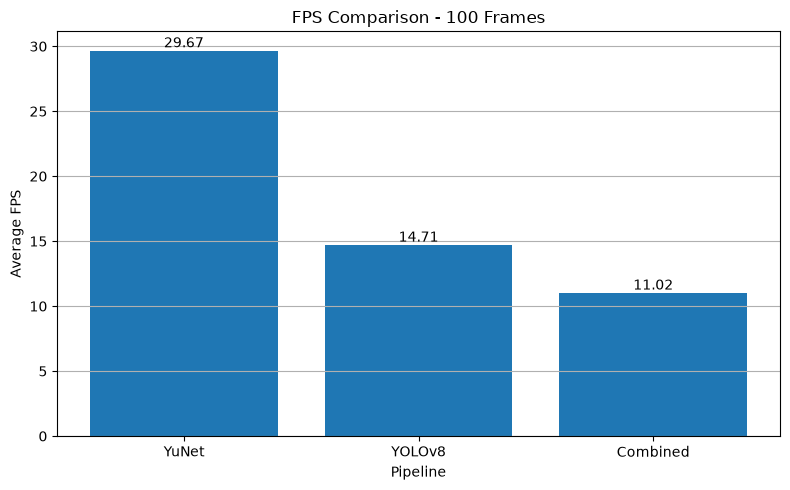

In [49]:
# Store model names
model_names = ["YuNet","YOLOv8","Combined"]

fps_values = [
    yunet_fps,
    yolo_fps,
    combined_fps
]
plt.figure(figsize=(8, 5))
plt.bar(model_names,fps_values)
plt.title("FPS Comparison - 100 Frames")
plt.xlabel("Pipeline")
plt.ylabel("Average FPS")

for i in range(len(fps_values)):

    plt.text(
        i,
        fps_values[i],
        str(round(fps_values[i], 2)),
        ha="center",
        va="bottom"
    )

plt.grid(axis="y")

plt.tight_layout()
plt.show()

## 5.4 Final Results Comparison Table

In [50]:
import pandas as pd

comparison_table = pd.DataFrame({

    "Technique": [
        "Morphological Operations",
        "Bitwise Operations",
        "Histograms",
        "YuNet Face Detection",
        "YOLOv8 Object Detection",
        "YuNet + YOLOv8"
    ],

    "Type": [
        "Classical",
        "Classical",
        "Classical",
        "Deep Learning",
        "Deep Learning",
        "Deep Learning"
    ],

    "What It Detects": [
        "Noise and object regions",
        "Image regions and masks",
        "Brightness and intensity distribution",
        "Human faces and 5 landmarks",
        "General COCO objects",
        "Faces and general objects"
    ],

    "Lighting Robustness": [
        "Low to Medium",
        "Low to Medium",
        "Medium",
        "Medium to High",
        "Medium to High",
        "Medium to High"
    ],

    "Approx. FPS": [
        "Very High*",
        "Very High*",
        "Very High*",
        round(yunet_fps, 2),
        round(yolo_fps, 2),
        round(combined_fps, 2)
    ],

    "Best Use Case": [
        "Noise removal and shape processing",
        "Image masking and region operations",
        "Brightness and contrast analysis",
        "Real-time face detection",
        "General object detection",
        "Combined real-time vision"
    ]
})

# Display the table
display(comparison_table)

,Technique,Type,What It Detects,Lighting Robustness,Approx. FPS,Best Use Case
0,Morphological Operations,Classical,Noise and object regions,Low to Medium,Very High*,Noise removal and shape processing
1,Bitwise Operations,Classical,Image regions and masks,Low to Medium,Very High*,Image masking and region operations
2,Histograms,Classical,Brightness and intensity distribution,Medium,Very High*,Brightness and contrast analysis
3,YuNet Face Detection,Deep Learning,Human faces and 5 landmarks,Medium to High,29.67,Real-time face detection
4,YOLOv8 Object Detection,Deep Learning,General COCO objects,Medium to High,14.71,General object detection
5,YuNet + YOLOv8,Deep Learning,Faces and general objects,Medium to High,11.02,Combined real-time vision


### The last three FPS values

In [51]:
round(yunet_fps, 2)
round(yolo_fps, 2)
round(combined_fps, 2)

11.02

# 5.5 Reflection

### Final Reflection

This project showed how classical computer vision and deep-learning methods can be combined for real-time monitoring.

Classical preprocessing techniques such as morphological opening can be used to reduce small noise before detection. However, too much preprocessing can remove useful image details. Therefore, a small kernel such as 3×3 is more suitable for a real-time pipeline.

For face detection, YuNet provides a lightweight solution with face bounding boxes and five facial landmarks. For general object detection, YOLOv8 can detect multiple COCO objects such as persons, cars, dogs, and chairs.

For a real-time monitoring system, a practical combination is:

**Light morphological preprocessing + YuNet + YOLOv8n**

The lightweight YOLOv8n model provides a good balance between detection capability and computational cost. The actual FPS should be selected based on the results obtained in the 100-frame benchmark.

### Low-Power Edge Device

For a low-power edge device, I would:

- Use **YOLOv8n** instead of a larger model such as YOLOv8s.
- Keep the YuNet `score_threshold` around **0.9** initially.
- Reduce the input resolution if necessary.
- Use a small morphological kernel such as **3×3** only when noise is present.
- Prefer a higher FPS and lower computational cost for real-time operation.

If the system misses too many faces, the YuNet threshold can be reduced, for example from **0.9 to 0.7**, and the detection results can be compared again.

### Cloud Server

On a cloud server with more computational resources, I could:

- Try **YOLOv8s** instead of YOLOv8n.
- Use a higher input resolution when small objects are important.
- Experiment with YuNet score thresholds such as **0.7 and 0.9**.
- Compare detection accuracy and FPS before selecting the final configuration.

The main trade-off is between **detection quality, FPS, and computational cost**. A larger model may provide better detection in some difficult situations but normally requires more computation.



# Final Conclusion

This project demonstrates both classical computer vision and modern
deep-learning based computer vision.

First, morphological operations such as erosion, dilation, opening
and closing were applied to the binary image. These operations are
useful for removing noise, expanding objects and filling small gaps.

Bitwise operations were then used to perform logical operations on
image masks. Image histograms were used to understand grayscale and
colour intensity distributions.

YuNet was used for face detection. It provides face bounding boxes,
facial landmarks and confidence scores.

YOLOv8 was used for general object detection. It can detect multiple
COCO objects in a single image.

Finally, YuNet and YOLOv8 were combined into one real-time computer
vision pipeline. The FPS experiment shows the processing speed of
individual detectors and the combined system.

The project demonstrates how classical image processing can be used
together with deep-learning models in a practical computer vision
application.